# SECOP Data Investigation — Expediente C: contratación atípica

**Equipo 5 · Expediente C · Cundinamarca · vigencias 2024–2025**
**Integrantes:** Neyder Sebastián Orozco Villamil, Marco Antonio Díaz González y Miguel Ángel Espinosa Esparza
**Docente:** Ing. Elías Buitrago Bolívar
**Data Analytics (43390860), periodo 2026-2 · Universidad Central**

**Rol:** unidad de analítica de *Veeduría Abierta*, organización ficticia de control ciudadano con
capacidad limitada de revisión.

**Afirmación objeto de verificación (formulada por el docente):**
> *Algunas entidades del recorte presentan patrones contractuales que justifican una revisión prioritaria.*

### Convenciones
- 🟦 **PREPARADA:** celda del andamiaje, se ejecuta sin modificar.
- 🟨 **EQUIPO:** completada por el equipo.
- 🟥 **NO BORRAR:** evidencia necesaria para reproducibilidad.

> ⚠️ **Advertencia de alcance (nota metodológica del brief, §6).** Atipicidad **no** es sinónimo de
> irregularidad. Un patrón que se aparta del resto puede tener explicaciones legítimas. Todo el
> lenguaje de este cuaderno es de **anomalía estadística** y **priorización de revisión**. Los datos
> del recorte **no permiten imputar irregularidades** a ninguna entidad ni persona.

# SEMANA 1 — Construcción de la evidencia

## 1. Cargar el recorte asignado

Parámetros del recorte asignados por el docente (Matriz de asignación de casos, equipo 5):
**vigencia 2024-01-01 → 2025-12-31**, **territorio: Cundinamarca**, sin filtro por tipo de contrato
(ese filtro aplica solo al Expediente A).

In [1]:
# 🟦 PREPARADA — CONFIGURACIÓN Y DESCARGA
# Parámetros del caso (Matriz de asignación, equipo 5). Vigencia y territorio NO SE MODIFICAN.

EQUIPO = "G05"
EXPEDIENTE = "C"

VIGENCIA_DESDE = "2024-01-01"
VIGENCIA_HASTA = "2025-12-31"

DEPARTAMENTO = "Cundinamarca"
TIPO_CONTRATO = None          # el Expediente C usa el recorte sin filtro por tipo

# MODIFICADO POR EL EQUIPO, CON JUSTIFICACIÓN (ver la celda siguiente).
# El andamiaje traía MAX_FILAS = 50_000 y una sola llamada. El recorte real tiene 101.475
# contratos: ese límite habría truncado la mitad del caso.
MAX_FILAS = 150_000
PAGINA = 25_000               # la API entrega un bloque por llamada; se pagina con $offset

# ------------------------------------------------------------
# Desde aquí no es necesario modificar nada
# ------------------------------------------------------------

from pathlib import Path
from io import StringIO
from datetime import datetime, timezone
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

API_URL = "https://www.datos.gov.co/resource/jbjy-vk9h.csv"

ARCHIVO_RECORTE = "secop_recorte.csv.gz"


def localizar_carpeta_datos():
    """Devuelve la carpeta data/raw exista donde exista.

    En local el cuaderno se abre dentro de su propia carpeta y basta la ruta
    relativa. En Google Colab el directorio de trabajo es /content, asi que se
    busca tambien el repositorio clonado. Si no aparece por ningun lado, se
    devuelve la ruta por defecto y la seccion siguiente descarga el recorte.
    """
    aqui = Path.cwd()
    posibles = [Path("data/raw")]
    posibles += [p / "data" / "raw" for p in [aqui, *aqui.parents][:5]]
    if Path("/content").exists():                      # estamos en Colab
        posibles += sorted(Path("/content").glob("*/**/data/raw"))

    for candidata in posibles:
        if (candidata / ARCHIVO_RECORTE).exists():
            return candidata
    return Path("data/raw")


CARPETA = localizar_carpeta_datos()
ARCHIVO = CARPETA / ARCHIVO_RECORTE
METADATA = CARPETA / "metadata_extraccion.json"

CARPETA.mkdir(parents=True, exist_ok=True)
print(f"Carpeta de datos: {CARPETA.resolve()}")


def construir_filtro():
    inicio = pd.Timestamp(VIGENCIA_DESDE)
    fin = pd.Timestamp(VIGENCIA_HASTA) + pd.Timedelta(days=1)

    condiciones = [
        f"fecha_de_firma >= '{inicio:%Y-%m-%dT00:00:00}'",
        f"fecha_de_firma < '{fin:%Y-%m-%dT00:00:00}'",
    ]

    if DEPARTAMENTO:
        valor = str(DEPARTAMENTO).replace("'", "''")
        condiciones.append(f"departamento = '{valor}'")

    if TIPO_CONTRATO:
        valor = str(TIPO_CONTRATO).replace("'", "''")
        condiciones.append(f"tipo_de_contrato = '{valor}'")

    return " AND ".join(condiciones)


if ARCHIVO.exists():

    print("✓ Usando la copia guardada del recorte.")
    df_raw = pd.read_csv(ARCHIVO, dtype=str)

else:

    print("Descargando el recorte desde SECOP II (con paginación)...")

    partes, offset = [], 0

    while offset < MAX_FILAS:

        respuesta = requests.get(
            API_URL,
            params={
                "$where": construir_filtro(),
                "$limit": PAGINA,
                "$offset": offset,
                "$order": "fecha_de_firma ASC, id_contrato ASC",
            },
            timeout=300,
        )
        respuesta.raise_for_status()

        pagina = pd.read_csv(StringIO(respuesta.text), dtype=str)
        print(f"  offset {offset:>7,} -> {len(pagina):>6,} filas")

        if pagina.empty:
            break

        partes.append(pagina)
        offset += PAGINA

        if len(pagina) < PAGINA:
            break

    df_raw = pd.concat(partes, ignore_index=True)

    if df_raw.empty:
        raise ValueError(
            "La consulta no devolvió registros. "
            "Informe al profesor antes de continuar."
        )

    df_raw.to_csv(ARCHIVO, index=False, compression="gzip")

    with METADATA.open("w", encoding="utf-8") as archivo_meta:
        json.dump(
            {
                "equipo": EQUIPO,
                "expediente": EXPEDIENTE,
                "dataset": "SECOP II - Contratos Electrónicos",
                "dataset_id": "jbjy-vk9h",
                "filtro": construir_filtro(),
                "fecha_extraccion_utc": datetime.now(
                    timezone.utc
                ).isoformat(timespec="seconds"),
                "registros": int(len(df_raw)),
            },
            archivo_meta,
            ensure_ascii=False,
            indent=2,
        )

    print(f"✓ Copia guardada en {ARCHIVO}")

print()
print(f"Equipo: {EQUIPO} | Expediente: {EXPEDIENTE}")
print(f"✓ Datos listos: {len(df_raw):,} filas x {df_raw.shape[1]} columnas")

Carpeta de datos: C:\Users\seb83\Documentos\Universidad\Data Analitycs\Talleres\Laboratorio SECOP II-20260920\data\raw
✓ Usando la copia guardada del recorte.



Equipo: G05 | Expediente: C
✓ Datos listos: 101,475 filas x 85 columnas


### 🟥 NO BORRAR — Incidencia en la sección 1: el límite de descarga truncaba el caso

El andamiaje traía `MAX_FILAS = 50_000` y una única llamada a la API. El recorte asignado
(**Cundinamarca, 2024–2025**) contiene **101.475 contratos**: con el parámetro original se habrían
descargado 50.000 filas, es decir **el 49,3 % del caso**. Y como la consulta ordena por
`fecha_de_firma ASC`, el corte no habría sido aleatorio: habría eliminado **el final del periodo**,
es decir buena parte de 2025. Un análisis de *concentración temporal de firmas* —que es el núcleo del
Expediente C— habría quedado invalidado de raíz, y el sesgo no habría sido visible en ninguna tabla.

**Decisión:** elevar `MAX_FILAS` y paginar la descarga con `$offset`, dejando **intacto** el filtro
del recorte (vigencia y territorio), que sí es inmodificable según el brief (§4).

Esta incidencia se reporta al docente, tal como lo pide el propio código preparado
(`⚠ El recorte alcanzó el límite configurado. Informe al profesor...`).

## 2. Registrar el caso

**Afirmación que investigará el equipo:**
> Algunas entidades del recorte (Cundinamarca, 2024–2025) presentan patrones contractuales que
> justifican una revisión prioritaria.

**Rol o cliente:**
> Unidad de analítica de *Veeduría Abierta*. El cliente no puede revisar 101.475 contratos ni 275
> entidades: necesita una **lista corta y ordenada** de entidades para mirar primero, con la razón
> explícita de por qué cada una entró a la lista.

**¿Qué tendría que observar en los datos para considerar que la afirmación tiene respaldo?**
> Que existan entidades cuyo perfil contractual se aparte de forma marcada del de **entidades
> comparables del mismo recorte** —no de un ideal abstracto— en indicadores observables, y que ese
> apartamiento **sobreviva** al control de las explicaciones alternativas evidentes: el régimen de
> contratación aplicable, la composición del objeto contractual y la cobertura de reporte.
> Si al comparar pares el perfil de todas las entidades cae dentro de un rango estrecho, la
> afirmación **no** tendría respaldo.

No formulamos todavía el veredicto.

## 2.1 🟨 EQUIPO — Criterio previo del equipo (brief del Expediente C, §3)

> **Registrado antes de observar cualquier resultado.** Este bloque fija qué contará como indicio de
> atipicidad y contra qué referencia se compara cada entidad, para que el hallazgo no se elija
> después de ver los datos.

### Indicadores observables que el equipo considerará indicios de atipicidad

| # | Indicador | Definición operativa | Pedido por el brief |
|---|---|---|---|
| **I1** | Proporción de **contratación directa** | contratos cuya `modalidad_de_contratacion` empieza por *Contratación directa*, sobre el total de la entidad | sí (§3) |
| **I2** | **Concentración temporal** de firmas | HHI sobre la distribución de `fecha_de_firma` en los 24 meses del recorte: `Σ pₘ²`. Vale 1/24 ≈ 0,042 si las firmas se reparten uniformemente y 1 si todo se firma en un solo mes | sí (§3) |
| **I3** | **Cuantía mediana** del contrato | mediana de `valor_del_contrato` de la entidad; se usa mediana y no media por las colas pesadas de SECOP | sí (§5) |

### Referencia de comparación (decidida antes de mirar resultados)

Cada entidad se compara contra la **mediana de su grupo de pares**: entidades del **mismo orden
administrativo** y la **misma clase institucional** dentro del recorte (alcaldías y municipios entre
sí; ESE y hospitales entre sí; etc.). La construcción y la justificación de esos pares se documentan
en la **sección 8**. El brief (§5) exige explícitamente que esta elección quede documentada.

### Regla de señalamiento (umbral fijado de antemano)

Se usa el **z robusto** dentro del grupo de pares:

$$z = \frac{x - \text{mediana}}{1{,}4826 \times \text{MAD}}$$

Se prefiere sobre el z clásico porque las distribuciones de SECOP tienen colas pesadas: la media y
la desviación estándar serían arrastradas por los extremos (cápsula 1, diap. 10).

- `z ≥ 2` en **un** indicador → la entidad entra a la lista de revisión;
- `z ≥ 2` en **dos o más** indicadores → prioridad alta;
- **ninguna** entidad con `z ≥ 2` → la afirmación **no** queda respaldada por este criterio.

### Qué NO contará como indicio

Un valor alto de **I1** que se explique íntegramente por el **régimen de contratación aplicable** a
la entidad, ni un valor alto de **I2** que se explique por **cobertura de reporte incompleta**.
Ambas condiciones se verifican y se controlan **antes** de señalar a ninguna entidad.

# 3. Preparación técnica mínima

La siguiente celda **no limpia** los datos. Únicamente convierte variables a formatos útiles y crea
variables auxiliares. El DataFrame original queda conservado en `df_raw`.

> **Nota sobre la lectura de las cifras.** La celda fija además el formato con que pandas *muestra* los números. Sin ese ajuste, las cuantías se imprimen en notación científica (`9.556710e+07` en lugar de `95.567.104`), que es correcta pero ilegible. **No se altera ningún dato:** solo cambia la representación en pantalla.

In [2]:
# 🟦 PREPARADA — TIPOS Y VARIABLES AUXILIARES

df = df_raw.copy()

# Variables numéricas comunes
for columna in [
    "valor_del_contrato",
    "valor_de_pago_adelantado",
    "valor_facturado",
    "valor_pendiente_de_pago",
]:
    if columna in df.columns:
        df[columna] = pd.to_numeric(df[columna], errors="coerce")

# Variables de fecha comunes
for columna in [
    "fecha_de_firma",
    "fecha_de_inicio_del_contrato",
    "fecha_de_fin_del_contrato",
]:
    if columna in df.columns:
        df[columna] = pd.to_datetime(df[columna], errors="coerce")

# Variables derivadas de uso frecuente
if (
    "fecha_de_inicio_del_contrato" in df.columns
    and "fecha_de_fin_del_contrato" in df.columns
):
    df["duracion_dias"] = (
        df["fecha_de_fin_del_contrato"] - df["fecha_de_inicio_del_contrato"]
    ).dt.days

if "fecha_de_firma" in df.columns:
    df["mes_firma"] = df["fecha_de_firma"].dt.month
    df["anio_firma"] = df["fecha_de_firma"].dt.year

if "valor_del_contrato" in df.columns and "duracion_dias" in df.columns:
    meses = df["duracion_dias"] / 30.4
    df["valor_mensual_aprox"] = df["valor_del_contrato"] / meses.where(meses > 0)

# --- Cómo se MUESTRAN los números (no cambia ningún dato) -------------------
# Sin esto, pandas imprime las cuantías en notación científica: el valor
# 95.567.104 aparece como 9.556710e+07, que es ilegible para el lector.
def formato_numero(x):
    """Separador de miles para cifras grandes; decimales para proporciones."""
    if pd.isna(x):
        return ""
    if abs(x) >= 1000:
        return f"{x:,.0f}"
    return f"{x:.4f}".rstrip("0").rstrip(".") or "0"

pd.set_option("display.float_format", formato_numero)

print("✓ Preparación técnica completada.")
print("✓ No se ha eliminado ninguna fila.")

✓ Preparación técnica completada.
✓ No se ha eliminado ninguna fila.


# 4. Primer contacto con el recorte

Antes de analizar una variable específica, revisamos el tamaño, las columnas y algunos registros.

In [3]:
# 🟦 PREPARADA — PRIMER CONTACTO

print(f"Filas: {len(df):,}")
print(f"Columnas: {df.shape[1]}")

if "fecha_de_firma" in df.columns:
    print(
        "Periodo observado:",
        df["fecha_de_firma"].min(),
        "→",
        df["fecha_de_firma"].max(),
    )

display(df.head(5))

resumen_columnas = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "faltantes": df.isna().sum(),
    "unicos": df.nunique(dropna=True),
})

display(resumen_columnas)

Filas: 101,475
Columnas: 89
Periodo observado: 2024-01-01 00:00:00 → 2025-12-31 00:00:00


,nombre_entidad,nit_entidad,departamento,ciudad,localizaci_n,orden,sector,rama,entidad_centralizada,proceso_de_compra,...,nombre_ordenador_de_pago,tipo_de_documento_ordenador_de_pago,n_mero_de_documento_ordenador_de_pago,documentos_tipo,descripcion_documentos_tipo,direcci_n_de_ejecuci_n_del_contrato,duracion_dias,mes_firma,anio_firma,valor_mensual_aprox
0,empresa social del estado región de salud soacha.,800006850,Cundinamarca,Soacha,"Colombia, Cundinamarca, Soacha",Territorial,Salud y Protección Social,Corporación Autónoma,Centralizada,CO1.BDOS.5353131,...,No definido,No definido,No definido,No,No definido,CL 13 10 48\nSoacha\nCundinamarca\nCOLOMBIA,365,1,2024,"3,830,783"
1,empresa social del estado región de salud soacha.,800006850,Cundinamarca,Soacha,"Colombia, Cundinamarca, Soacha",Territorial,Salud y Protección Social,Corporación Autónoma,Centralizada,CO1.BDOS.5354286,...,No definido,No definido,No definido,No,No definido,CL 13 10 48\nSoacha\nCundinamarca\nCOLOMBIA,319,1,2024,"4,406,933"
2,empresa social del estado región de salud soacha.,800006850,Cundinamarca,Soacha,"Colombia, Cundinamarca, Soacha",Territorial,Salud y Protección Social,Corporación Autónoma,Centralizada,CO1.BDOS.5355150,...,No definido,No definido,No definido,No,No definido,CL 13 10 48\nSoacha\nCundinamarca\nCOLOMBIA,365,1,2024,"7,319,117"
3,empresa social del estado región de salud soacha.,800006850,Cundinamarca,Soacha,"Colombia, Cundinamarca, Soacha",Territorial,Salud y Protección Social,Corporación Autónoma,Centralizada,CO1.BDOS.5355140,...,No definido,No definido,No definido,No,No definido,CL 13 10 48\nSoacha\nCundinamarca\nCOLOMBIA,365,1,2024,"11,993,425"
4,empresa social del estado región de salud soacha.,800006850,Cundinamarca,Soacha,"Colombia, Cundinamarca, Soacha",Territorial,Salud y Protección Social,Corporación Autónoma,Centralizada,CO1.BDOS.5355157,...,DIEGO ALEJANDRO GARCIA LONDOÑO,Cédula de Ciudadanía,11.221.245,No,No definido,CL 13 10 48\nSoacha\nCundinamarca\nCOLOMBIA,61,1,2024,"1,920,283"


,tipo,faltantes,unicos
nombre_entidad,str,0,336
nit_entidad,str,0,275
departamento,str,0,1
ciudad,str,0,102
localizaci_n,str,0,108
...,...,...,...
direcci_n_de_ejecuci_n_del_contrato,str,0,454
duracion_dias,float64,754,759
mes_firma,int32,0,12
anio_firma,int32,0,2


In [4]:
# 🟨 EQUIPO — PERFIL GENERAL (cápsula 1, diap. 3: las cinco preguntas antes de todo)

print("1. ¿Cuántos contratos hay realmente?")
print(f"   filas: {len(df):,} | id_contrato únicos: {df['id_contrato'].nunique():,}")
print(f"   referencia_del_contrato únicos: {df['referencia_del_contrato'].nunique():,}")

print("\n2. ¿Cuántas entidades y proveedores distintos?")
print(f"   nit_entidad únicos      : {df['nit_entidad'].nunique():,}")
print(f"   nombre_entidad únicos   : {df['nombre_entidad'].nunique():,}   <-- no coinciden")
print(f"   documento_proveedor únicos: {df['documento_proveedor'].nunique():,}")

print("\n3. ¿Qué periodo cubre de verdad el recorte?")
print(f"   {df['fecha_de_firma'].min():%Y-%m-%d} → {df['fecha_de_firma'].max():%Y-%m-%d}")

print("\n4. Composición institucional del recorte (orden administrativo):")
display(df["orden"].value_counts().to_frame("contratos"))

print("5. Estado de los contratos:")
display(df["estado_contrato"].value_counts().to_frame("contratos"))

1. ¿Cuántos contratos hay realmente?
   filas: 101,475 | id_contrato únicos: 101,475
   referencia_del_contrato únicos: 68,696

2. ¿Cuántas entidades y proveedores distintos?
   nit_entidad únicos      : 275
   nombre_entidad únicos   : 336   <-- no coinciden
   documento_proveedor únicos: 43,225

3. ¿Qué periodo cubre de verdad el recorte?
   2024-01-01 → 2025-12-31

4. Composición institucional del recorte (orden administrativo):


,contratos
orden,
Territorial,89480
Nacional,10927
Corporación Autónoma,1068


5. Estado de los contratos:


,contratos
estado_contrato,
Cerrado,32949
En ejecución,30583
Modificado,20443
terminado,16380
Aprobado,791
cedido,207
Suspendido,122


### 🟨 EQUIPO — lectura inicial

**Dos aspectos del recorte que llamaron la atención del equipo:**

1. **`nit_entidad` no identifica a la entidad contratante.** Hay **275 NIT** pero **336 nombres de
   entidad**. Al revisar los casos, el patrón es sistemático: el municipio, su concejo y su
   personería **comparten el NIT municipal** (por ejemplo, el NIT `899999712` aparece como
   *Municipio de La Calera*, *Concejo Municipal de La Calera* y *Personería Municipal de La Calera*).
   Son tres unidades de contratación distintas, con presupuestos y volúmenes muy distintos. La
   cápsula 1 (diap. 8) recomienda agrupar proveedores por NIT y no por razón social; **para
   entidades, en este recorte, la regla se invierte** y hay que justificarlo.

2. **El recorte no es un universo homogéneo.** Conviven 89.480 contratos del orden *Territorial*,
   10.927 del orden *Nacional* (SENA, INPEC, unidades militares con sede en el departamento) y 1.068
   de *Corporación Autónoma*. Comparar una alcaldía municipal con una escuela del INPEC en
   "proporción de contratación directa" no mide atipicidad: mide que son cosas distintas.

**¿Qué aspecto debería verificarse antes de utilizar estos datos para responder la afirmación?**

> La **cobertura de reporte por entidad**. SECOP II se alimenta del reporte de cada entidad; si una
> entidad solo publicó durante parte del periodo, su distribución de fechas de firma aparecerá
> artificialmente concentrada. Como I2 (concentración temporal) es uno de los indicadores exigidos
> por el brief, este chequeo es una condición previa y no un detalle: se verifica en la sección 7.

# 5. Elegir las variables de trabajo

El Expediente C (§5) pide caracterizar el comportamiento contractual **por entidad** en tres
dimensiones: composición por modalidad, distribución de fechas de firma y distribución de cuantías.
Las variables se eligen para servir a esos tres indicadores.

In [5]:
# 🟨 EQUIPO — VARIABLES SEGÚN EL EXPEDIENTE C

VARIABLE_NUMERICA = "valor_del_contrato"        # I3: distribución de cuantías
VARIABLE_CATEGORICA = "modalidad_de_contratacion"  # I1: composición por modalidad
VARIABLE_IDENTIFICADOR = "id_contrato"

# Segundas variables que el expediente sí requiere
VARIABLE_NUMERICA_2 = "duracion_dias"           # control de la semana 2
VARIABLE_CATEGORICA_2 = "tipo_de_contrato"      # confusora candidata (composición del objeto)

# Unidad de análisis del expediente
VARIABLE_ENTIDAD = "nombre_entidad"
VARIABLE_FECHA = "fecha_de_firma"               # I2: concentración temporal

print("Variable numérica     :", VARIABLE_NUMERICA)
print("Variable categórica   :", VARIABLE_CATEGORICA)
print("Variable numérica 2   :", VARIABLE_NUMERICA_2)
print("Variable categórica 2 :", VARIABLE_CATEGORICA_2)
print("Unidad de análisis    :", VARIABLE_ENTIDAD)
print("Variable de fecha     :", VARIABLE_FECHA)

Variable numérica     : valor_del_contrato
Variable categórica   : modalidad_de_contratacion
Variable numérica 2   : duracion_dias
Variable categórica 2 : tipo_de_contrato
Unidad de análisis    : nombre_entidad
Variable de fecha     : fecha_de_firma


In [6]:
# 🟦 PREPARADA — PALETA Y ESTILO DE LAS FIGURAS
# Paleta Okabe-Ito: cualitativa y segura para daltonismo. Los colores se asignan en orden fijo,
# nunca cíclico, y el texto usa tinta neutra (nunca el color de la serie).

AZUL      = "#0072B2"   # entidad o categoría destacada
NARANJA   = "#E69F00"
VERDE     = "#009E73"
BERMELLON = "#D55E00"
GRIS      = "#9AA0A6"   # el grupo de pares, siempre recesivo
TINTA     = "#202124"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#C8CCD0",
    "axes.labelcolor": TINTA,
    "text.color": TINTA,
    "xtick.color": TINTA,
    "ytick.color": TINTA,
    "axes.grid": True,
    "grid.color": "#E8EAED",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "figure.autolayout": True,
})

def pesos(x, _=None):
    """Formatea cuantías colombianas en millones/miles de millones."""
    if x >= 1e9:
        return f"${x/1e9:,.1f} MM"
    if x >= 1e6:
        return f"${x/1e6:,.1f} M"
    return f"${x:,.0f}"

# --- Formato de los EJES de las figuras -------------------------------------
# matplotlib, ante cifras grandes, rotula el eje 0.0 / 0.2 / 0.4 y deja un
# "1e9" suelto en la esquina. Es ilegible: estas ayudas lo evitan.
from matplotlib.ticker import FuncFormatter, NullFormatter

plt.rcParams["axes.formatter.useoffset"] = False     # nada de desplazamientos
plt.rcParams["axes.formatter.limits"] = (-9, 9)      # nada de notación científica


def pesos_eje(x, _=None):
    """Versión corta de `pesos` para rotular ejes, sin decimales."""
    if abs(x) >= 1e9:
        return f"${x/1e9:,.0f} MM"
    if abs(x) >= 1e6:
        return f"${x/1e6:,.0f} M"
    if abs(x) >= 1e3:
        return f"${x/1e3:,.0f} mil"
    return f"${x:,.0f}"


def ejes_legibles(ax, x=None, y=None):
    """Aplica a cada eje el formato pedido: "pesos" o "miles"."""
    for eje, modo in ((ax.xaxis, x), (ax.yaxis, y)):
        if modo == "pesos":
            eje.set_major_formatter(FuncFormatter(pesos_eje))
            eje.set_minor_formatter(NullFormatter())
        elif modo == "miles":
            eje.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
    return ax


print("✓ Estilo de figuras configurado (paleta Okabe-Ito).")

✓ Estilo de figuras configurado (paleta Okabe-Ito).


# 6. EDA univariado

## 6.1 Variable numérica — `valor_del_contrato`

,resultado
count,"101,475"
mean,"95,567,104"
std,"1,633,587,262"
min,0
25%,"9,142,070"
50%,"17,500,000"
75%,"33,000,000"
max,"202,173,502,349"


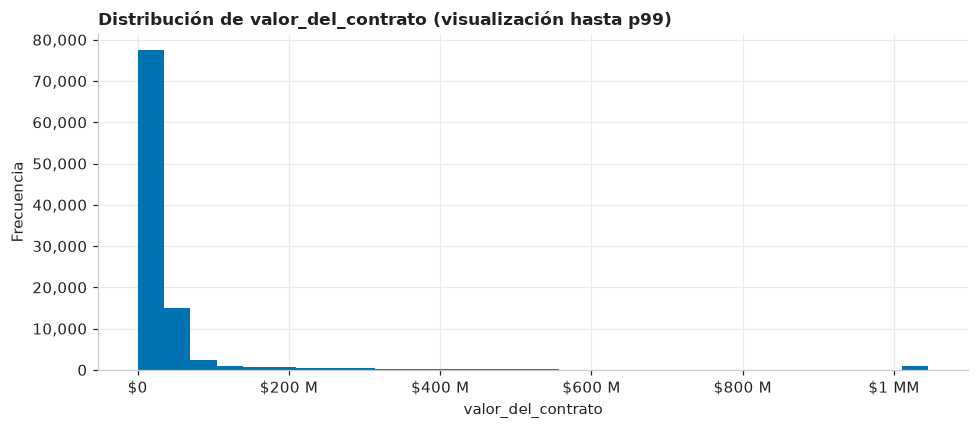

In [7]:
# 🟦 PREPARADA — VARIABLE NUMÉRICA

serie = pd.to_numeric(df[VARIABLE_NUMERICA], errors="coerce").dropna()

display(serie.describe(percentiles=[0.25, 0.50, 0.75]).to_frame("resultado"))

if len(serie) > 0:
    limite_visual = serie.quantile(0.99)

    plt.figure(figsize=(9, 4))
    serie.clip(upper=limite_visual).hist(bins=30, color=AZUL)
    plt.xlabel(VARIABLE_NUMERICA)
    plt.ylabel("Frecuencia")
    plt.title(f"Distribución de {VARIABLE_NUMERICA} (visualización hasta p99)")
    ejes_legibles(plt.gca(), x="pesos", y="miles")
    plt.show()

In [8]:
# 🟨 EQUIPO — LA TRAMPA DE LA MEDIA, CUANTIFICADA (cápsula 1, diap. 10)

media = serie.mean()
mediana = serie.median()
p95, p99 = serie.quantile(0.95), serie.quantile(0.99)

resumen_cuantias = pd.Series({
    "media": media,
    "mediana": mediana,
    "P25": serie.quantile(0.25),
    "P75": serie.quantile(0.75),
    "P95": p95,
    "P99": p99,
    "máximo": serie.max(),
}).map(pesos)
display(resumen_cuantias.to_frame("valor_del_contrato"))

print(f"La media es {media/mediana:.1f} veces la mediana.")

n_top = max(1, int(len(serie) * 0.001))
top = serie.nlargest(n_top)
print(
    f"El 0,1 % de contratos más grandes ({n_top:,} contratos) concentra "
    f"{100 * top.sum() / serie.sum():.1f} % del valor total del recorte."
)
print(f"Contratos registrados en $0: {(serie == 0).sum():,}")

,valor_del_contrato
media,$95.6 M
mediana,$17.5 M
P25,$9.1 M
P75,$33.0 M
P95,$155.8 M
P99,$1.0 MM
máximo,$202.2 MM


La media es 5.5 veces la mediana.
El 0,1 % de contratos más grandes (101 contratos) concentra 35.0 % del valor total del recorte.
Contratos registrados en $0: 719


### 🟨 EQUIPO — interpretación

- **¿Media o mediana para describir un caso "típico"?** La **mediana**. La media
  (**\$95,6 M**) es **5,5 veces** la mediana (**\$17,5 M**): está arrastrada por la cola. El
  0,1 % de contratos más grandes —101 contratos— concentra el **35 % del valor total** del recorte.
  Reportar la media como "el contrato típico de Cundinamarca" sería engañoso.
- **¿Simétrica o sesgada?** Fuertemente **asimétrica a la derecha**, la forma normal en SECOP
  (cápsula 1, diap. 6). El histograma está recortado a p99 justamente porque en escala lineal la
  cola aplasta todo lo demás.
- **¿Qué merece revisión?** Los **719 contratos registrados en \$0** (convenios sin cuantía
  inicial, errores de captura o registros pendientes: tres causas con tres tratamientos distintos) y
  el extremo superior, donde el contrato máximo supera los \$202.000 millones. Ninguno de los dos
  grupos se elimina en silencio: se tratan en la sección 7.1.

## 6.2 Variable categórica — `modalidad_de_contratacion`

,registros
modalidad_de_contratacion,
Contratación directa,71808
Contratación régimen especial,18276
Mínima cuantía,6847
Selección Abreviada de Menor Cuantía,1520
Contratación Directa (con ofertas),792
Selección abreviada subasta inversa,786
Contratación régimen especial (con ofertas),707
Licitación pública,339
Concurso de méritos abierto,265


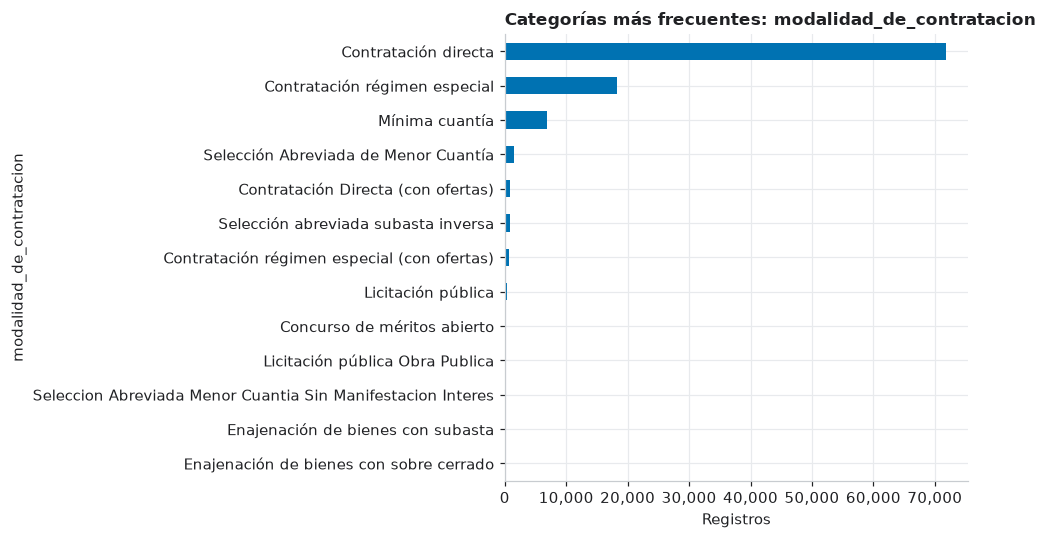

In [9]:
# 🟦 PREPARADA — VARIABLE CATEGÓRICA

frecuencias = df[VARIABLE_CATEGORICA].value_counts(dropna=False).head(15)

display(frecuencias.to_frame("registros"))

plt.figure(figsize=(9, 5))
frecuencias.sort_values().plot(kind="barh", color=AZUL)
plt.xlabel("Registros")
plt.ylabel(VARIABLE_CATEGORICA)
plt.title(f"Categorías más frecuentes: {VARIABLE_CATEGORICA}")
ejes_legibles(plt.gca(), x="miles")
plt.show()

### 🟨 EQUIPO — interpretación

El recorte está **muy concentrado**: la contratación directa reúne **72.600 de 101.475 contratos
(71,6 %)** y, sumada al régimen especial, cubre más del **90 %** del recorte. Las modalidades
competitivas (licitación pública, concurso de méritos, selección abreviada) son residuales en número
de contratos.

Dos consecuencias para el Expediente C:

1. **Una proporción alta de contratación directa es la norma, no la excepción.** Un indicador que
   señale "contratación directa alta" sin una referencia de pares señalaría a casi todo el
   departamento. La comparación contra pares, que el brief exige, no es un refinamiento: es lo único
   que hace informativo al indicador.
2. **La categoría está fragmentada.** Existen *Contratación directa* y *Contratación Directa (con
   ofertas)* como etiquetas separadas, igual que *Contratación régimen especial* y su variante
   *(con ofertas)*. Contarlas por separado subestimaría el indicador I1: se agrupan por prefijo.

# 7. Calidad de datos

Observamos primero. **No eliminamos ni corregimos automáticamente.**

In [10]:
# 🟦 PREPARADA — CALIDAD BÁSICA

variables = [VARIABLE_IDENTIFICADOR, VARIABLE_NUMERICA, VARIABLE_CATEGORICA]

for extra in [VARIABLE_NUMERICA_2, VARIABLE_CATEGORICA_2]:
    if extra:
        variables.append(extra)

variables = [v for v in variables if v in df.columns]

calidad = pd.DataFrame({
    "faltantes": df[variables].isna().sum(),
    "porcentaje_faltante": (df[variables].isna().mean() * 100).round(1),
    "valores_unicos": df[variables].nunique(dropna=True),
})

display(calidad)

if VARIABLE_IDENTIFICADOR in df.columns:
    print(
        "Identificadores repetidos:",
        f"{df[VARIABLE_IDENTIFICADOR].duplicated(keep=False).sum():,}",
    )

serie = pd.to_numeric(df[VARIABLE_NUMERICA], errors="coerce")

q1 = serie.quantile(0.25)
q3 = serie.quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

print(
    "Posibles valores extremos por IQR:",
    int(((serie < limite_inferior) | (serie > limite_superior)).sum()),
)

,faltantes,porcentaje_faltante,valores_unicos
id_contrato,0,0,101475
valor_del_contrato,0,0,33380
modalidad_de_contratacion,0,0,13
duracion_dias,754,0.7,759
tipo_de_contrato,0,0,19


Identificadores repetidos: 0
Posibles valores extremos por IQR: 9084


In [11]:
# 🟨 EQUIPO — DIAGNÓSTICO 1: ¿QUÉ LLAVE IDENTIFICA A LA ENTIDAD?

nombres_por_nit = (
    df.groupby("nit_entidad")["nombre_entidad"].nunique().sort_values(ascending=False)
)

print(f"NIT con más de un nombre de entidad: {(nombres_por_nit > 1).sum()} de {len(nombres_por_nit)}")

ejemplo = nombres_por_nit.index[0]
print(f"\nEjemplo — NIT {ejemplo}:")
for nombre in sorted(df.loc[df.nit_entidad == ejemplo, "nombre_entidad"].unique()):
    n = int((df.nombre_entidad == nombre).sum())
    print(f"   · {nombre}  ({n:,} contratos)")

print("\nNo son variantes ortográficas del mismo ente: son unidades de contratación distintas")
print("(municipio, concejo y personería comparten el NIT municipal).")

NIT con más de un nombre de entidad: 43 de 275

Ejemplo — NIT 899999712:
   · CONCEJO MUNICIPAL DE LA CALERA - CUNDINAMARCA  (31 contratos)
   · MUNICIPIO DE LA CALERA CUNDINAMARCA  (1,009 contratos)
   · Personería Municipal de La Calera  (10 contratos)

No son variantes ortográficas del mismo ente: son unidades de contratación distintas
(municipio, concejo y personería comparten el NIT municipal).


In [12]:
# 🟨 EQUIPO — DIAGNÓSTICO 2: COBERTURA DE REPORTE POR ENTIDAD
# Condición previa para que I2 (concentración temporal) signifique algo.

df["mes_periodo"] = df[VARIABLE_FECHA].dt.to_period("M")

cobertura = (
    df.groupby(VARIABLE_ENTIDAD)
    .agg(
        contratos=("id_contrato", "size"),
        primer_mes=("mes_periodo", "min"),
        ultimo_mes=("mes_periodo", "max"),
        meses_activos=("mes_periodo", "nunique"),
    )
    .sort_values("contratos", ascending=False)
)

grandes = cobertura[cobertura.contratos >= 100]

print(f"Entidades con al menos 100 contratos: {len(grandes)}")
print(f"De ellas, con menos de 18 meses activos (de 24 posibles): {(grandes.meses_activos < 18).sum()}")

print("\nLas 8 de menor cobertura:")
display(grandes.nsmallest(8, "meses_activos"))

Entidades con al menos 100 contratos: 141
De ellas, con menos de 18 meses activos (de 24 posibles): 16

Las 8 de menor cobertura:


,contratos,primer_mes,ultimo_mes,meses_activos
nombre_entidad,,,,
E.S.E HOSPITAL NUESTRA SEÑORA DEL CARMEN DE TABIO,127,2024-01,2024-03,3
ALCALDIA MUNICIPAL DE VIOTÁ,104,2024-01,2025-12,6
E.S.E HOSPITAL SAN FRANCISCO DE GACHETA,414,2024-03,2024-11,9
E.S.E. HOSPITAL SAN ANTONIO DEL TEQUENDAMA,197,2024-01,2024-12,9
MUNICIPIO DE APULO,173,2024-05,2025-12,12
MUNICIPIO DE PANDI,123,2024-01,2025-12,13
ESE HOSPITAL SAN JOSE DE GUADUAS,839,2024-11,2025-12,14
ALCALDIA DE SESQUILE,403,2024-11,2025-12,14


In [13]:
# 🟨 EQUIPO — DIAGNÓSTICO 3: CUANTÍAS EN $0 Y EXTREMOS

ceros = df[df[VARIABLE_NUMERICA] == 0]
print(f"Contratos en $0: {len(ceros):,} ({100*len(ceros)/len(df):.2f} % del recorte)")
print("\n¿Dónde se concentran? (tipo de contrato):")
display(ceros[VARIABLE_CATEGORICA_2].value_counts().head(5).to_frame("contratos en $0"))

print("Los 5 contratos de mayor cuantía del recorte:")
display(
    df.nlargest(5, VARIABLE_NUMERICA)[
        [VARIABLE_ENTIDAD, VARIABLE_CATEGORICA_2, VARIABLE_CATEGORICA, VARIABLE_NUMERICA]
    ].assign(**{VARIABLE_NUMERICA: lambda t: t[VARIABLE_NUMERICA].map(pesos)})
)

Contratos en $0: 719 (0.71 % del recorte)

¿Dónde se concentran? (tipo de contrato):


,contratos en $0
tipo_de_contrato,
Comodato,257
Otro,204
Arrendamiento de inmuebles,113
Prestación de servicios,104
Decreto 092 de 2017,17


Los 5 contratos de mayor cuantía del recorte:


,nombre_entidad,tipo_de_contrato,modalidad_de_contratacion,valor_del_contrato
16750,empresa social del estado región de salud soacha.,Obra,Contratación régimen especial (con ofertas),$202.2 MM
78136,DEPARTAMENTO DE CUNDINAMARCA-SECRETARIA DE HAC...,Operaciones de Crédito Público,Contratación directa,$195.0 MM
80803,DEPARTAMENTO DE CUNDINAMARCA-SECRETARIA DE HAC...,Operaciones de Crédito Público,Contratación directa,$159.3 MM
76215,ALCALDÍA MUNICIPAL COTA,Operaciones de Crédito Público,Contratación directa,$153.5 MM
98927,DEPARTAMENTO DE CUNDINAMARCA-SECRETARIA DE HAC...,Operaciones de Crédito Público,Contratación directa,$150.0 MM


## 7.1 Tres decisiones de preparación

> Cada decisión se documenta con la situación encontrada, la decisión tomada, la evidencia numérica
> que la respalda y qué cambiaría si la decisión fuera equivocada (cápsula 1, diap. 11).

---

### Decisión 1 — La unidad de análisis es `nombre_entidad`, no `nit_entidad`

- **Situación encontrada.** El recorte tiene **275 NIT** y **336 nombres de entidad**. En **43 NIT**
  aparece más de un nombre, y la inspección muestra que no son variantes ortográficas del mismo ente:
  el **municipio, el concejo y la personería comparten el NIT municipal** (NIT `899999712` →
  *Municipio de La Calera* + *Concejo Municipal de La Calera* + *Personería Municipal de La Calera*).
- **Decisión.** Agrupar por **`nombre_entidad`**. Se revisó además que no existan variantes
  ortográficas del mismo nombre que obliguen a normalizar texto.
- **Evidencia.** Celda "DIAGNÓSTICO 1": 43 de 275 NIT con más de un nombre, con el desglose del caso
  ejemplo y el volumen de contratos de cada unidad.
- **Si la decisión fuera equivocada.** Agrupar por NIT fusionaría una alcaldía (miles de contratos)
  con su concejo y su personería (decenas). El indicador I1 de la entidad fusionada sería un
  promedio ponderado sin significado, y las personerías —que contratan poquísimo y casi todo por
  directa— quedarían invisibles. **Esta decisión contradice deliberadamente la regla general de la
  cápsula 1 (diap. 8)**, que recomienda agrupar por identificador numérico: esa regla está escrita
  para *proveedores*, donde el NIT identifica una sola persona jurídica. Para *entidades
  territoriales colombianas*, el NIT es municipal y lo comparten varios entes contratantes.

---

### Decisión 2 — Marco de comparación: orden territorial, ≥ 100 contratos y ≥ 18 meses de reporte

- **Situación encontrada.** Tres problemas simultáneos:
  (a) el recorte mezcla órdenes administrativos (89.480 territoriales, 10.927 nacionales, 1.068 de
  corporación autónoma) que no son comparables entre sí;
  (b) muchas entidades tienen muy pocos contratos, y un porcentaje calculado sobre 20 contratos
  "baila" con cada registro nuevo (cápsula 2, diap. 6);
  (c) **15 de las 119 entidades territoriales con ≥ 100 contratos reportan en menos de 18 de los
  24 meses** (16 de 141 si se cuentan todos los órdenes).
- **Decisión.** El marco de comparación se restringe a entidades del **orden Territorial**, con
  **≥ 100 contratos** y **≥ 18 meses activos**.
- **Evidencia.** Celda "DIAGNÓSTICO 2". La ESE *Hospital Nuestra Señora del Carmen de Tabio* solo
  reporta **3 meses** (enero–marzo de 2024) y concentra el **77 % de sus contratos en un solo mes**;
  la *Alcaldía Municipal de Viotá* reporta **6 meses** y el 97 % de sus contratos caen entre octubre
  y diciembre de 2025. Sin este filtro, **ambas encabezan el ranking de I2**.
- **Si la decisión fuera equivocada.** Si la baja cobertura no fuera un artefacto de reporte sino
  una entidad que realmente dejó de contratar, estaríamos **excluyendo un hallazgo real**. Por eso
  las 15 entidades no se borran: se separan y se entregan al cliente como **lista aparte de
  "revisar la completitud del reporte"**, que es una observación de control en sí misma. En
  dirección contraria, si no filtráramos, el indicador I2 mediría calidad del reporte y no
  comportamiento contractual, y la lista de priorización estaría **completamente equivocada**.

---

### Decisión 3 — Los $0 y los megacontratos se conservan; cambia la estadística, no el dato

- **Situación encontrada.** **719 contratos en \$0** y una cola extrema (máximo > \$202.000
  millones; **9.084 registros** señalados como valores extremos por la regla del IQR).
- **Decisión.** **No se elimina ninguna fila.** Los \$0 se excluyen **solo** del cálculo de la
  cuantía mediana (I3), donde un valor no informado no es una cuantía; se conservan íntegros para
  I1 e I2, donde la cuantía es irrelevante. Los extremos se conservan **siempre** y se describen con
  **mediana y percentiles** en lugar de media.
- **Evidencia.** Celdas "LA TRAMPA DE LA MEDIA" y "DIAGNÓSTICO 3": media \$95,6 M frente a mediana
  \$17,5 M (5,5×); el 0,1 % mayor concentra el 35 % del valor.
- **Si la decisión fuera equivocada.** Si los \$0 fueran en realidad errores de captura de contratos
  con cuantía real, estaríamos subestimando el volumen contratado de las entidades que los
  concentran. Si los megacontratos fueran errores de unidad (pesos registrados como miles), la
  cuantía mediana por entidad se distorsionaría — pero como usamos **mediana**, un puñado de errores
  extremos casi no la mueve: esa es exactamente la razón de preferirla. Eliminar los extremos, en
  cambio, sería amputar evidencia: en esta investigación **el outlier puede ser la historia**
  (cápsula 1, diap. 9).

In [14]:
# 🟨 EQUIPO — APLIQUE AQUÍ SOLO LAS DECISIONES JUSTIFICADAS

# Decisión 1: la unidad de análisis es nombre_entidad (no se altera el DataFrame, se fija la llave).
# Decisión 3: no se elimina ninguna fila.
df_analisis = df.copy()

# Decisión 2: el MARCO DE COMPARACIÓN se construye aquí. No borra datos de df_analisis:
# define qué entidades son comparables entre sí.
MIN_CONTRATOS = 100
MIN_MESES_REPORTE = 18

print(f"Datos originales : {len(df):,}")
print(f"Datos para análisis: {len(df_analisis):,}  (no se eliminó ninguna fila)")
print(f"\nParámetros del marco de comparación: n >= {MIN_CONTRATOS}, meses activos >= {MIN_MESES_REPORTE}")

Datos originales : 101,475
Datos para análisis: 101,475  (no se eliminó ninguna fila)

Parámetros del marco de comparación: n >= 100, meses activos >= 18


# 8. Extensión específica del expediente

El Expediente C exige una operación que el andamiaje genérico no trae: **construir los pares de
comparación** y **calcular el perfil contractual de cada entidad**. El brief (§5) es explícito en que
*"la comparación entre entidades debe hacerse frente a pares del mismo recorte y no frente a un ideal
abstracto; la elección de esos pares es una decisión que debe quedar documentada"*.

## 8.1 Cómo se definieron los pares

Los pares se construyen con **dos llaves observables en el propio dataset**:

1. **`orden`** — el orden administrativo, que ya viene en SECOP (*Territorial*, *Nacional*,
   *Corporación Autónoma*).
2. **`clase_entidad`** — una **variable derivada** por el equipo a partir de `nombre_entidad`, que
   separa alcaldías y municipios, ESE y hospitales, concejos, personerías, empresas de servicios
   públicos y el resto.

**¿Por qué hace falta la segunda llave?** Porque dentro del mismo orden territorial conviven
entidades sujetas a **regímenes de contratación distintos**. Es exactamente la explicación legítima
que anticipa el brief (§6: *"un régimen de contratación especial"*). La sección 8.3 lo cuantifica.

**Orden de las reglas de clasificación.** Las reglas se evalúan en un orden deliberado, porque los
nombres se solapan. *"Empresa de Servicios Públicos de Acueducto, Alcantarillado y Aseo del
**Municipio** de Apulo"* contiene la palabra *Municipio*: con las reglas en el orden ingenuo quedaba
clasificada como alcaldía, y aparecía como la alcaldía con **0 % de contratación directa** de todo el
recorte — un falso hallazgo puro. La regla de servicios públicos se evalúa **antes** que la de
municipio, y la de salud antes que la de servicios públicos (porque *"Empresa Social del Estado"*
también empieza por *Empresa*).

In [15]:
# 🟨 EQUIPO — EXTENSIÓN DEL EXPEDIENTE C: CLASE DE ENTIDAD Y PANEL DE INDICADORES

import re
import unicodedata


def clasificar_entidad(nombre):
    """Clase institucional a partir del nombre. El ORDEN de las reglas importa: ver 8.1."""
    t = unicodedata.normalize("NFKD", str(nombre)).encode("ascii", "ignore").decode().upper()
    t = re.sub(r"[^A-Z0-9 ]", " ", t)

    if "PERSONERIA" in t:
        return "Personería"
    if "CONCEJO" in t:
        return "Concejo"
    if re.search(r"\bE ?S ?E\b|HOSPITAL|SALUD", t):          # antes que EMPRESA
        return "Salud (ESE/Hospital)"
    if re.search(r"ACUEDUCTO|ALCANTARILLADO|SERVICIOS PUBLICOS|\bESP\b", t):  # antes que MUNICIPIO
        return "Empresa de servicios"
    if re.search(r"ALCALDIA|MUNICIPIO|GOBERNACION", t):
        return "Alcaldía/Municipio"
    return "Otro territorial"


df_analisis["clase_entidad"] = df_analisis[VARIABLE_ENTIDAD].map(clasificar_entidad)

# I1: la modalidad se agrupa por prefijo para no partir "Contratación directa (con ofertas)"
df_analisis["es_directa"] = (
    df_analisis[VARIABLE_CATEGORICA].str.strip().str.lower().str.startswith("contratación directa")
)
df_analisis["mes_periodo"] = df_analisis[VARIABLE_FECHA].dt.to_period("M")

print("Clases de entidad dentro del orden Territorial:")
display(
    pd.crosstab(
        df_analisis.loc[df_analisis.orden == "Territorial", "clase_entidad"],
        "contratos",
    ).rename(columns={"contratos": "contratos"})
)

Clases de entidad dentro del orden Territorial:


col_0,contratos
clase_entidad,
Alcaldía/Municipio,56436
Concejo,1890
Empresa de servicios,809
Otro territorial,12747
Personería,1786
Salud (ESE/Hospital),15812


In [16]:
# 🟨 EQUIPO — PANEL DE INDICADORES POR ENTIDAD (I1, I2, I3)

def hhi_mensual(meses):
    """Concentración temporal de las firmas: suma de los cuadrados de las proporciones mensuales.
    Reparto uniforme en 24 meses -> 1/24 = 0,0417. Todo en un solo mes -> 1,0."""
    p = meses.value_counts(normalize=True)
    return float((p ** 2).sum())


territorial = df_analisis[df_analisis.orden == "Territorial"]
grupos = territorial.groupby(VARIABLE_ENTIDAD)

panel = grupos.agg(
    clase_entidad=("clase_entidad", "first"),
    n_contratos=("id_contrato", "size"),
    I1_p_directa=("es_directa", "mean"),
    meses_activos=("mes_periodo", "nunique"),
)

# I2 y el mes pico se calculan aparte y se unen por índice (no por posición)
panel = panel.join(grupos["mes_periodo"].apply(hhi_mensual).rename("I2_hhi"))
panel = panel.join(
    grupos["mes_periodo"]
    .apply(lambda s: s.value_counts(normalize=True).max())
    .rename("pico_mes")
)

# Decisión 3: los $0 se excluyen SOLO del cálculo de la cuantía mediana
con_cuantia = territorial[territorial[VARIABLE_NUMERICA] > 0]
panel = panel.join(
    con_cuantia.groupby(VARIABLE_ENTIDAD)[VARIABLE_NUMERICA].median().rename("I3_cuantia_mediana")
)
panel = panel.join(
    territorial.groupby(VARIABLE_ENTIDAD)[VARIABLE_NUMERICA].sum().rename("valor_total")
)

# Decisión 2: marco de comparación
panel["comparable"] = (panel.n_contratos >= MIN_CONTRATOS) & (panel.meses_activos >= MIN_MESES_REPORTE)

excluidas = panel[(panel.n_contratos >= MIN_CONTRATOS) & (~panel.comparable)]

print(f"Entidades territoriales en el recorte      : {len(panel)}")
print(f"Con al menos {MIN_CONTRATOS} contratos     : {(panel.n_contratos >= MIN_CONTRATOS).sum()}")
print(f"Excluidas por cobertura de reporte < {MIN_MESES_REPORTE} meses : {len(excluidas)}")
print(f"ENTIDADES COMPARABLES                      : {panel.comparable.sum()}")

print("\nEntidades apartadas por cobertura (lista de 'revisar completitud del reporte'):")
display(
    excluidas[["clase_entidad", "n_contratos", "meses_activos", "I2_hhi", "pico_mes"]]
    .sort_values("meses_activos")
    .round(3)
)

Entidades territoriales en el recorte      : 288
Con al menos 100 contratos     : 119
Excluidas por cobertura de reporte < 18 meses : 15
ENTIDADES COMPARABLES                      : 104

Entidades apartadas por cobertura (lista de 'revisar completitud del reporte'):


,clase_entidad,n_contratos,meses_activos,I2_hhi,pico_mes
nombre_entidad,,,,,
E.S.E HOSPITAL NUESTRA SEÑORA DEL CARMEN DE TABIO,Salud (ESE/Hospital),127,3,0.628,0.772
ALCALDIA MUNICIPAL DE VIOTÁ,Alcaldía/Municipio,104,6,0.321,0.365
E.S.E HOSPITAL SAN FRANCISCO DE GACHETA,Salud (ESE/Hospital),414,9,0.28,0.481
E.S.E. HOSPITAL SAN ANTONIO DEL TEQUENDAMA,Salud (ESE/Hospital),197,9,0.242,0.355
MUNICIPIO DE APULO,Alcaldía/Municipio,173,12,0.132,0.197
MUNICIPIO DE PANDI,Alcaldía/Municipio,123,13,0.109,0.171
ALCALDIA DE SESQUILE,Alcaldía/Municipio,403,14,0.099,0.186
ALCALDIA MUNICIPAL DE SUTATAUSA,Alcaldía/Municipio,202,14,0.117,0.203
MUNICIPIO DE CAPARRAPI*,Alcaldía/Municipio,250,14,0.099,0.164


## 8.2 Cálculo del z robusto dentro de cada grupo de pares

Se aplica la regla registrada en el **criterio previo (§2.1)**, sin cambiarla.

In [17]:
# 🟨 EQUIPO — Z ROBUSTO DENTRO DE CADA GRUPO DE PARES

def z_robusto(s):
    """(x - mediana) / (1,4826 * MAD). Resistente a las colas pesadas de SECOP."""
    mediana = s.median()
    mad = (s - mediana).abs().median()
    if mad == 0 or pd.isna(mad):
        return pd.Series(0.0, index=s.index)
    return (s - mediana) / (1.4826 * mad)


INDICADORES = ["I1_p_directa", "I2_hhi", "I3_cuantia_mediana"]

comparables = panel[panel.comparable].copy()

for ind in INDICADORES:
    comparables["z_" + ind] = comparables.groupby("clase_entidad")[ind].transform(z_robusto)

cols_z = ["z_" + i for i in INDICADORES]
comparables["banderas"] = (comparables[cols_z] >= 2).sum(axis=1)
comparables["z_suma"] = comparables[cols_z].sum(axis=1)

print("Entidades comparables por clase:")
display(comparables.clase_entidad.value_counts().to_frame("entidades"))

print("Reparto de banderas (indicadores con z >= 2), según el umbral fijado en §2.1:")
display(comparables.banderas.value_counts().sort_index().to_frame("entidades"))

print(f"\nEntidades con PRIORIDAD ALTA (2 o más banderas): {(comparables.banderas >= 2).sum()}")
print(f"Entidades en LISTA DE REVISIÓN (1 bandera)     : {(comparables.banderas == 1).sum()}")

Entidades comparables por clase:


,entidades
clase_entidad,
Alcaldía/Municipio,52
Otro territorial,27
Personería,8
Salud (ESE/Hospital),7
Concejo,6
Empresa de servicios,4


Reparto de banderas (indicadores con z >= 2), según el umbral fijado en §2.1:


,entidades
banderas,
0,87
1,17



Entidades con PRIORIDAD ALTA (2 o más banderas): 0
Entidades en LISTA DE REVISIÓN (1 bandera)     : 17


## 8.3 Por qué los pares eran indispensables

La celda siguiente muestra el resultado que justifica toda la sección 8: **si se compara a todas las
entidades territoriales entre sí, el indicador I1 deja de medir lo que dice medir.**

In [18]:
# 🟨 EQUIPO — I1 POR CLASE DE ENTIDAD: EL RÉGIMEN APLICABLE DOMINA EL INDICADOR

perfil_clase = (
    territorial.groupby("clase_entidad")
    .agg(
        entidades=(VARIABLE_ENTIDAD, "nunique"),
        contratos=("id_contrato", "size"),
        p_directa=("es_directa", "mean"),
    )
    .sort_values("contratos", ascending=False)
)
perfil_clase["p_directa"] = (perfil_clase.p_directa * 100).round(1)
display(perfil_clase.rename(columns={"p_directa": "% contratación directa"}))

print("Composición por modalidad — Salud (ESE/Hospital):")
display(
    territorial.loc[territorial.clase_entidad == "Salud (ESE/Hospital)", VARIABLE_CATEGORICA]
    .value_counts(normalize=True)
    .mul(100).round(1).to_frame("% de sus contratos")
)

print("Composición por modalidad — Alcaldía/Municipio:")
display(
    territorial.loc[territorial.clase_entidad == "Alcaldía/Municipio", VARIABLE_CATEGORICA]
    .value_counts(normalize=True)
    .mul(100).round(1).head(5).to_frame("% de sus contratos")
)

,entidades,contratos,% contratación directa
clase_entidad,,,
Alcaldía/Municipio,96,56436,86.7
Salud (ESE/Hospital),26,15812,0.3
Otro territorial,61,12747,82.6
Concejo,51,1890,79.7
Personería,43,1786,87.1
Empresa de servicios,11,809,0


Composición por modalidad — Salud (ESE/Hospital):


,% de sus contratos
modalidad_de_contratacion,
Contratación régimen especial,98.9
Contratación régimen especial (con ofertas),0.8
Contratación directa,0.3


Composición por modalidad — Alcaldía/Municipio:


,% de sus contratos
modalidad_de_contratacion,
Contratación directa,85.7
Mínima cuantía,7.5
Selección Abreviada de Menor Cuantía,2.1
Selección abreviada subasta inversa,1
Contratación Directa (con ofertas),1


# 9. Evidence Board

Tres tarjetas, cada una rastreable hasta un bloque de este notebook.

---

## E1 — Composición por modalidad: el indicador solo significa algo dentro del grupo de pares

E1 · Alcaldías/municipios comparables : 52
E1 · I1 mediana del grupo             : 82.7%
E1 · I1 rango del grupo               : 61.4% a 97.4%
E1 · ESE/hospitales, % directa        : 0.3%
E1 · ESE/hospitales, % régimen especial: 99.7%

E1 · Máximo del grupo: MUNICIPIO DE SOACHA.
     I1 = 97.4% sobre 5,857 contratos
     z robusto = 1.90  (umbral de señalamiento: 2,0)
     distancia a la mediana del grupo = 14.7 puntos porcentuales


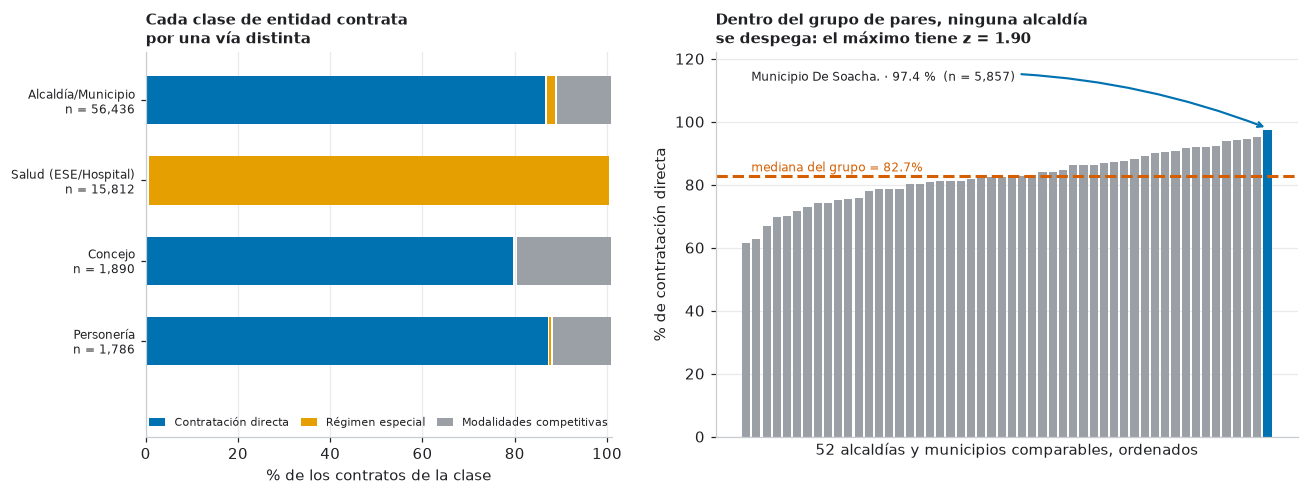

In [19]:
# 🟥 E1 — NO BORRAR — COMPOSICIÓN POR MODALIDAD Y DISPERSIÓN DENTRO DEL GRUPO DE PARES

alcaldias = comparables[comparables.clase_entidad == "Alcaldía/Municipio"]
ese = territorial[territorial.clase_entidad == "Salud (ESE/Hospital)"]

med_alc = alcaldias.I1_p_directa.median()
p_dir_ese = ese.es_directa.mean()
p_esp_ese = ese[VARIABLE_CATEGORICA].str.startswith("Contratación régimen especial").mean()

print(f"E1 · Alcaldías/municipios comparables : {len(alcaldias)}")
print(f"E1 · I1 mediana del grupo             : {med_alc:.1%}")
print(f"E1 · I1 rango del grupo               : {alcaldias.I1_p_directa.min():.1%} a {alcaldias.I1_p_directa.max():.1%}")
print(f"E1 · ESE/hospitales, % directa        : {p_dir_ese:.1%}")
print(f"E1 · ESE/hospitales, % régimen especial: {p_esp_ese:.1%}")

extremo = alcaldias.I1_p_directa.idxmax()
print(f"\nE1 · Máximo del grupo: {extremo}")
print(f"     I1 = {alcaldias.loc[extremo, 'I1_p_directa']:.1%} sobre {int(alcaldias.loc[extremo,'n_contratos']):,} contratos")
print(f"     z robusto = {alcaldias.loc[extremo, 'z_I1_p_directa']:.2f}  (umbral de señalamiento: 2,0)")
print(f"     distancia a la mediana del grupo = {100*(alcaldias.loc[extremo,'I1_p_directa']-med_alc):.1f} puntos porcentuales")

# --- Figura E1: dos paneles, misma escala, n visible ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [1, 1.25]})

clases = ["Alcaldía/Municipio", "Salud (ESE/Hospital)", "Concejo", "Personería"]
directa, especial, otras, etiquetas = [], [], [], []
for c in clases:
    sub = territorial[territorial.clase_entidad == c]
    d = sub.es_directa.mean() * 100
    e = sub[VARIABLE_CATEGORICA].str.startswith("Contratación régimen especial").mean() * 100
    directa.append(d); especial.append(e); otras.append(100 - d - e)
    etiquetas.append(f"{c}\nn = {len(sub):,}")

y = np.arange(len(clases))
ax1.barh(y, directa, color=AZUL, label="Contratación directa", height=0.6)
ax1.barh(y, especial, left=np.array(directa) + 0.4, color=NARANJA, label="Régimen especial", height=0.6)
ax1.barh(y, otras, left=np.array(directa) + np.array(especial) + 0.8, color=GRIS, label="Modalidades competitivas", height=0.6)
ax1.set_yticks(y, etiquetas, fontsize=8)
ax1.invert_yaxis()
ax1.set_ylim(4.2, -0.6)          # banda libre abajo para la leyenda
ax1.set_xlim(0, 101)
ax1.set_xlabel("% de los contratos de la clase")
ax1.set_title("Cada clase de entidad contrata\npor una vía distinta", fontsize=10)
ax1.legend(fontsize=7.5, loc="lower center", ncol=3, framealpha=0, columnspacing=1.0,
           handlelength=1.4, borderpad=0.2)
ax1.grid(axis="y", visible=False)

vals = alcaldias.I1_p_directa.sort_values() * 100
colores = [AZUL if i == vals.index[-1] else GRIS for i in vals.index]
ax2.bar(range(len(vals)), vals.values, color=colores, width=0.8)
ax2.axhline(med_alc * 100, color=BERMELLON, lw=2, ls="--")
ax2.text(0.5, med_alc * 100 + 1.5, f"mediana del grupo = {med_alc:.1%}",
         fontsize=8, color=BERMELLON)          # etiqueta directa, sin caja de leyenda
ax2.set_xticks([])
ax2.set_ylim(0, 122)
ax2.set_xlabel(f"{len(vals)} alcaldías y municipios comparables, ordenados")
ax2.set_ylabel("% de contratación directa")
ax2.set_title("Dentro del grupo de pares, ninguna alcaldía\nse despega: el máximo tiene z = %.2f" % alcaldias.loc[extremo, "z_I1_p_directa"], fontsize=10)
ax2.annotate(f"{extremo.title()} · {vals.iloc[-1]:.1f} %  (n = {int(alcaldias.loc[extremo,'n_contratos']):,})",
             xy=(len(vals) - 1, vals.iloc[-1] + 0.5), xytext=(0.5, 113),
             fontsize=8, color=TINTA,
             arrowprops=dict(arrowstyle="->", color=AZUL, lw=1.4,
                             connectionstyle="arc3,rad=-0.12"))

plt.show()

### Tarjeta E1

| Campo | Contenido |
|---|---|
| **Hallazgo** | La proporción de contratación directa **no separa entidades atípicas mientras no se compare con pares**: las ESE y hospitales del recorte tramitan casi todo por régimen especial y las alcaldías casi todo por contratación directa, así que un ranking único del departamento ordena las entidades por el régimen que les aplica, no por su comportamiento. Una vez formado el grupo de alcaldías y municipios comparables, **ninguna se despega de sus pares**: el máximo del grupo se queda por debajo del umbral que el equipo fijó antes de mirar los datos. |
| **Cifra** | Las **ESE/hospitales** tramitan **99,7 %** de sus contratos por régimen especial y **0,3 %** por contratación directa; las **alcaldías**, **86,7 %** por contratación directa. Entre las **52 alcaldías comparables**, la mediana de contratación directa es **82,7 %**, el rango va de **61,4 % a 97,4 %**, y el máximo (Municipio de Soacha, **97,4 %** sobre **5.857** contratos) alcanza un **z robusto de 1,90**, por debajo del umbral de 2,0 fijado en §2.1. |
| **Fuente en el notebook** | **E1** (sección 9), con el panel de indicadores de la sección 8.2. |
| **Hipótesis explicativa** | La modalidad está determinada en primer lugar por el **marco normativo aplicable a la entidad** (las ESE contratan bajo régimen especial de salud) y en segundo lugar por la **composición de su objeto contractual**. La dispersión que queda dentro del grupo de alcaldías es compatible con diferencias de tamaño y de estructura de plantilla, no necesariamente con un comportamiento anómalo. |
| **Duda pendiente** | Falta descomponer I1 **por tipo de contrato**. Si las alcaldías con mayor I1 son simplemente las que más prestación de servicios contratan —donde la contratación directa es la vía prevista—, el indicador estaría midiendo composición del objeto y no discrecionalidad. **Esta duda es la que da origen a la objeción de la semana 2.** |

---

## E2 — Concentración temporal de firmas: el indicador mide, en primer lugar, cobertura de reporte

E2 · Ranking CRUDO de I2 (sin filtrar por cobertura de reporte):


,clase_entidad,n_contratos,meses_activos,I2_hhi,pico_mes
nombre_entidad,,,,,
E.S.E HOSPITAL NUESTRA SEÑORA DEL CARMEN DE TABIO,Salud (ESE/Hospital),127,3,0.628,0.772
ALCALDIA MUNICIPAL DE VIOTÁ,Alcaldía/Municipio,104,6,0.321,0.365
EMPRESA SOCIAL DEL ESTADO HOSPITAL SAN RAFAEL DE FACATATIVA,Salud (ESE/Hospital),210,17,0.297,0.481
E.S.E HOSPITAL SAN FRANCISCO DE GACHETA,Salud (ESE/Hospital),414,9,0.28,0.481
E.S.E. HOSPITAL SAN ANTONIO DEL TEQUENDAMA,Salud (ESE/Hospital),197,9,0.242,0.355
CUNDEPORTES RICAURTE,Otro territorial,129,18,0.197,0.279


E2 · Ranking tras aplicar la Decisión 2 (cobertura >= 18 meses):


,n_contratos,meses_activos,I2_hhi,pico_mes,z_I2_hhi
nombre_entidad,,,,,
ALCALDÍA MUNICIPAL DE SOPO,1126,24,0.111,0.198,3.695
ALCALDIA MUNICIPAL DE SUESCA +,231,18,0.103,0.208,3.064
INSTITUTO DE DEPORTES Y RECREACIÓN DEL MUNICIPIO DE FACATATIVA,286,22,0.097,0.227,2.582
ALCALDIA MUNICIPAL DE GUADUAS,364,18,0.094,0.154,2.301
MUNICIPIO DE TOCANCIPA,1391,24,0.089,0.156,1.906
ALCALDIA MUNICIPAL DE GACHETA,321,22,0.088,0.159,1.829



E2 · HHI mediano del grupo de alcaldías : 0.0667  (uniforme en 24 meses = 0.0417)
E2 · Máximo: ALCALDÍA MUNICIPAL DE SOPO -> HHI 0.1108, z = 3.70
     concentra 19.8% de sus 1,126 contratos en un solo mes
     (mediana del grupo en el mes pico: 12.9%)

E2 · Enero+febrero de 2024 = 21.8% de las firmas de 2024
E2 · Enero+febrero de 2025 = 37.7% de las firmas de 2025


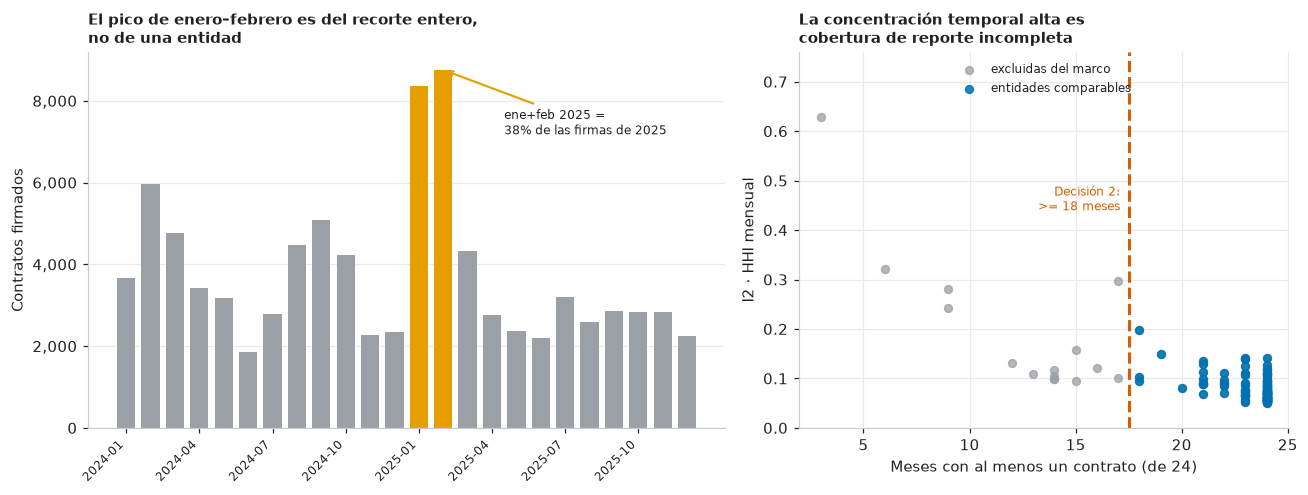

In [20]:
# 🟥 E2 — NO BORRAR — CONCENTRACIÓN TEMPORAL DE LAS FIRMAS

print("E2 · Ranking CRUDO de I2 (sin filtrar por cobertura de reporte):")
crudo = panel[panel.n_contratos >= MIN_CONTRATOS].nlargest(6, "I2_hhi")
display(crudo[["clase_entidad", "n_contratos", "meses_activos", "I2_hhi", "pico_mes"]].round(3))

print("E2 · Ranking tras aplicar la Decisión 2 (cobertura >= 18 meses):")
alc2 = comparables[comparables.clase_entidad == "Alcaldía/Municipio"]
display(alc2.nlargest(6, "I2_hhi")[["n_contratos", "meses_activos", "I2_hhi", "pico_mes", "z_I2_hhi"]].round(3))

med_hhi = alc2.I2_hhi.median()
top_hhi = alc2.I2_hhi.idxmax()
print(f"\nE2 · HHI mediano del grupo de alcaldías : {med_hhi:.4f}  (uniforme en 24 meses = {1/24:.4f})")
print(f"E2 · Máximo: {top_hhi} -> HHI {alc2.loc[top_hhi,'I2_hhi']:.4f}, z = {alc2.loc[top_hhi,'z_I2_hhi']:.2f}")
print(f"     concentra {alc2.loc[top_hhi,'pico_mes']:.1%} de sus {int(alc2.loc[top_hhi,'n_contratos']):,} contratos en un solo mes")
print(f"     (mediana del grupo en el mes pico: {alc2.pico_mes.median():.1%})")

# El patrón de fondo del recorte completo
por_anio = territorial.groupby(territorial[VARIABLE_FECHA].dt.year)["mes_periodo"].value_counts(normalize=True)
ef24 = por_anio.loc[2024].reindex([pd.Period("2024-01"), pd.Period("2024-02")]).sum()
ef25 = por_anio.loc[2025].reindex([pd.Period("2025-01"), pd.Period("2025-02")]).sum()
print(f"\nE2 · Enero+febrero de 2024 = {ef24:.1%} de las firmas de 2024")
print(f"E2 · Enero+febrero de 2025 = {ef25:.1%} de las firmas de 2025")

# --- Figura E2 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [1.3, 1]})

serie_mes = territorial.mes_periodo.value_counts().sort_index()
x = np.arange(len(serie_mes))
colores = [NARANJA if str(p) in ("2025-01", "2025-02") else GRIS for p in serie_mes.index]
ax1.bar(x, serie_mes.values, color=colores, width=0.75)
ax1.set_xticks(x[::3], [str(p) for p in serie_mes.index[::3]], rotation=45, ha="right", fontsize=8)
ax1.set_ylabel("Contratos firmados")
ejes_legibles(ax1, y="miles")
ax1.set_title("El pico de enero–febrero es del recorte entero,\nno de una entidad", fontsize=10)
ax1.annotate(f"ene+feb 2025 =\n{ef25:.0%} de las firmas de 2025",
             xy=(13, serie_mes.iloc[13]), xytext=(15.5, serie_mes.max() * 0.82),
             fontsize=8, color=TINTA,
             arrowprops=dict(arrowstyle="->", color=NARANJA, lw=1.4))
ax1.grid(axis="x", visible=False)

sin_filtro = panel[panel.n_contratos >= MIN_CONTRATOS]
ax2.scatter(sin_filtro.meses_activos, sin_filtro.I2_hhi, s=26, color=GRIS,
            alpha=0.75, label="excluidas del marco", zorder=2)
ax2.scatter(comparables.meses_activos, comparables.I2_hhi, s=26, color=AZUL,
            alpha=0.85, label="entidades comparables", zorder=3)
ax2.axvline(MIN_MESES_REPORTE - 0.5, color=BERMELLON, lw=2, ls="--")
ax2.text(MIN_MESES_REPORTE - 0.9, 0.44, f"Decisión 2:\n>= {MIN_MESES_REPORTE} meses",
         fontsize=8, ha="right", color=BERMELLON)
ax2.set_ylim(0, 0.76)
ax2.set_xlabel("Meses con al menos un contrato (de 24)")
ax2.set_ylabel("I2 · HHI mensual")
ax2.set_title("La concentración temporal alta es\ncobertura de reporte incompleta", fontsize=10)
ax2.legend(fontsize=8, loc="upper center", framealpha=0)

plt.show()

### Tarjeta E2

| Campo | Contenido |
|---|---|
| **Hallazgo** | Las entidades que aparentan la mayor concentración temporal de firmas **no contratan de forma atípica: reportan de forma incompleta**. Corregido eso, la concentración temporal restante es un **patrón común a todo el departamento** —el pico de renovación de contratos de enero y febrero— y no un rasgo distintivo de ninguna entidad. |
| **Cifra** | Las **5 entidades** con mayor HHI del ranking crudo reportan entre **3 y 17 meses** de los 24 posibles (la ESE de Tabio: **3 meses**, con **77,2 %** de sus contratos en un solo mes; la Alcaldía de Viotá: **6 meses**, HHI 0,321). Aplicada la Decisión 2, el HHI mediano de las **52 alcaldías comparables** es **0,067** (reparto uniforme = 0,042) y el máximo —Alcaldía de Sopó, **z = 3,70**— concentra **19,8 %** de sus **1.126** contratos en un solo mes. En el recorte completo, **enero + febrero de 2025 reúnen el 37,8 %** de las firmas de ese año, frente al **21,8 %** de enero + febrero de 2024. |
| **Fuente en el notebook** | **E2** (sección 9), con el diagnóstico de cobertura de la sección 7 y el marco de la sección 8.2. |
| **Hipótesis explicativa** | El pico de enero–febrero es compatible con el **ciclo presupuestal anual**: los contratos de prestación de servicios se firman o renuevan al comenzar la vigencia fiscal. El caso de Sopó, único por encima del umbral, es compatible con ese mismo ciclo **amplificado** por una entidad que concentra más su calendario de contratación. |
| **Duda pendiente** | El HHI mensual **no distingue** entre "firmar mucho en enero" (ciclo presupuestal) y "firmar mucho en un mes cualquiera" (que sí sería llamativo). Haría falta un indicador de concentración **ajustado por el mes del año**, o mirar la concentración en ventanas cortas (días) en lugar de meses. También conviene verificar si las 15 entidades apartadas tienen reporte incompleto o realmente dejaron de contratar. |

---

## E3 — Distribución de cuantías: dónde está el dinero del recorte

E3 · Contratos con cuantía > 0 : 100,756
E3 · Media                     : $96.2 M
E3 · Mediana                   : $17.6 M
E3 · La media es 5.5 veces la mediana
E3 · El 0,1 % mayor (100 contratos) concentra 34.9 % del valor

E3 · Cuantía mediana del grupo de alcaldías : $16.2 M
E3 · Máximo: MUNICIPIO DE TOCANCIPA -> $29.2 M, z = 2.27
E3 · Rango del grupo: $9.4 M a $29.2 M

E3 · Ranking compuesto (suma de los tres z) — lista corta para el cliente:


,n_contratos,I1_p_directa,z_I1_p_directa,I2_hhi,z_I2_hhi,I3_cuantia_mediana,z_I3_cuantia_mediana,banderas,z_suma
nombre_entidad,,,,,,,,,
ALCALDÍA MUNICIPAL DE SOPO,1126,0.916,1.146,0.111,3.695,"23,436,875",1.261,1,6.103
MUNICIPIO DE TOCANCIPA,1391,0.944,1.513,0.089,1.906,"29,239,322",2.271,1,5.69
ALCALDÍA MUNICIPAL COTA,3120,0.939,1.45,0.087,1.736,"27,200,000",1.916,0,5.102
ALCALDIA MUNICIPAL DE CHIA,2469,0.919,1.19,0.084,1.411,"23,625,000",1.294,0,3.896
MUNICIPIO DE SOACHA.,5857,0.974,1.905,0.086,1.646,"16,000,000",-0.032,0,3.518
MUNICIPIO DE TENJO,1148,0.891,0.829,0.08,1.1,"23,877,129",1.338,0,3.267
ALCALDIA MUNICIPIO DE CAJICA,1452,0.84,0.17,0.075,0.677,"28,184,000",2.087,1,2.935
MUNICIPIO DE FUNZA - ALCALDÍA DE FUNZA,2646,0.942,1.485,0.078,0.958,"18,900,000",0.472,0,2.915


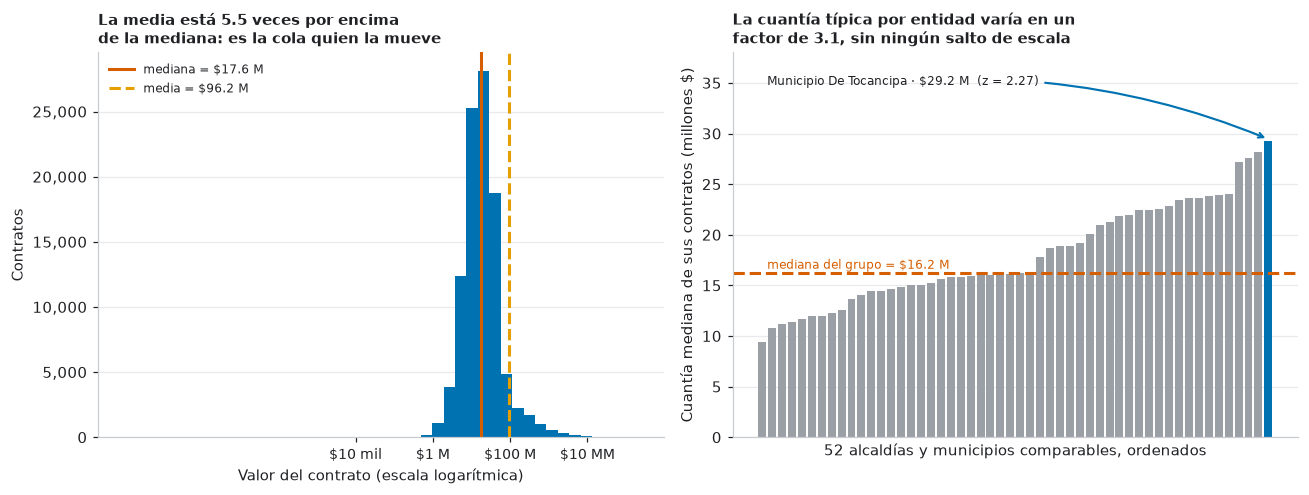

In [21]:
# 🟥 E3 — NO BORRAR — DISTRIBUCIÓN DE CUANTÍAS Y CONCENTRACIÓN DEL VALOR

val = df_analisis.loc[df_analisis[VARIABLE_NUMERICA] > 0, VARIABLE_NUMERICA]

print(f"E3 · Contratos con cuantía > 0 : {len(val):,}")
print(f"E3 · Media                     : {pesos(val.mean())}")
print(f"E3 · Mediana                   : {pesos(val.median())}")
print(f"E3 · La media es {val.mean()/val.median():.1f} veces la mediana")

n_top = int(len(val) * 0.001)
print(f"E3 · El 0,1 % mayor ({n_top:,} contratos) concentra {100*val.nlargest(n_top).sum()/val.sum():.1f} % del valor")

med_i3 = alcaldias.I3_cuantia_mediana.median()
top_i3 = alcaldias.I3_cuantia_mediana.idxmax()
print(f"\nE3 · Cuantía mediana del grupo de alcaldías : {pesos(med_i3)}")
print(f"E3 · Máximo: {top_i3} -> {pesos(alcaldias.loc[top_i3,'I3_cuantia_mediana'])}, z = {alcaldias.loc[top_i3,'z_I3_cuantia_mediana']:.2f}")
print(f"E3 · Rango del grupo: {pesos(alcaldias.I3_cuantia_mediana.min())} a {pesos(alcaldias.I3_cuantia_mediana.max())}")

print("\nE3 · Ranking compuesto (suma de los tres z) — lista corta para el cliente:")
display(
    alcaldias.nlargest(8, "z_suma")[
        ["n_contratos", "I1_p_directa", "z_I1_p_directa", "I2_hhi", "z_I2_hhi",
         "I3_cuantia_mediana", "z_I3_cuantia_mediana", "banderas", "z_suma"]
    ].round(3)
)

# --- Figura E3 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))

ax1.hist(np.log10(val), bins=45, color=AZUL)
ax1.axvline(np.log10(val.median()), color=BERMELLON, lw=2,
            label=f"mediana = {pesos(val.median())}")
ax1.axvline(np.log10(val.mean()), color=NARANJA, lw=2, ls="--",
            label=f"media = {pesos(val.mean())}")
ax1.set_xticks([4, 6, 8, 10], ["$10 mil", "$1 M", "$100 M", "$10 MM"], fontsize=9)
ax1.set_xlabel("Valor del contrato (escala logarítmica)")
ax1.set_ylabel("Contratos")
ejes_legibles(ax1, y="miles")
ax1.set_title(f"La media está {val.mean()/val.median():.1f} veces por encima\nde la mediana: es la cola quien la mueve", fontsize=10)
ax1.legend(fontsize=8, loc="upper left", framealpha=0)
ax1.grid(axis="x", visible=False)

orden_i3 = alcaldias.I3_cuantia_mediana.sort_values()
factor = orden_i3.iloc[-1] / orden_i3.iloc[0]
colores = [AZUL if i == orden_i3.index[-1] else GRIS for i in orden_i3.index]
ax2.bar(range(len(orden_i3)), orden_i3.values / 1e6, color=colores, width=0.8)
ax2.axhline(med_i3 / 1e6, color=BERMELLON, lw=2, ls="--")
ax2.text(0.5, med_i3 / 1e6 + 0.45, f"mediana del grupo = {pesos(med_i3)}",
         fontsize=8, color=BERMELLON)          # etiqueta directa, sin caja de leyenda
ax2.set_xticks([])
ax2.set_ylim(0, orden_i3.iloc[-1] / 1e6 * 1.30)
ax2.set_xlabel(f"{len(orden_i3)} alcaldías y municipios comparables, ordenados")
ax2.set_ylabel("Cuantía mediana de sus contratos (millones $)")
ax2.set_title(f"La cuantía típica por entidad varía en un\nfactor de {factor:.1f}, sin ningún salto de escala", fontsize=10)
ax2.annotate(f"{top_i3.title()} · {pesos(orden_i3.iloc[-1])}  (z = {alcaldias.loc[top_i3,'z_I3_cuantia_mediana']:.2f})",
             xy=(len(orden_i3) - 1, orden_i3.iloc[-1] / 1e6 + 0.2),
             xytext=(0.5, orden_i3.iloc[-1] / 1e6 * 1.19),
             fontsize=8, color=TINTA,
             arrowprops=dict(arrowstyle="->", color=AZUL, lw=1.4,
                             connectionstyle="arc3,rad=-0.12"))

plt.show()

### Tarjeta E3

| Campo | Contenido |
|---|---|
| **Hallazgo** | El valor del recorte está **extremadamente concentrado en pocos contratos**, pero esa concentración **no se traduce en entidades atípicas**: la cuantía típica por entidad varía de forma continua entre alcaldías comparables, sin ningún salto de escala que permita separar un grupo del resto. Para el cliente, esto significa que **la lista de priorización no puede construirse mirando cuantías**: priorizar por tamaño llevaría a revisar siempre a los municipios más grandes. |
| **Cifra** | Entre los **100.756** contratos con cuantía informada, la media (**\$96,2 M**) es **5,5 veces** la mediana (**\$17,6 M**), y el **0,1 % de contratos mayores (100 contratos) concentra el 34,9 % del valor total**. Entre las **52 alcaldías comparables**, la cuantía mediana por entidad va de **\$9,4 M a \$29,2 M** —un factor de 3— con mediana de grupo **\$16,2 M**; el máximo (Municipio de Tocancipá, **\$29,2 M**) alcanza **z = 2,27**. |
| **Fuente en el notebook** | **E3** (sección 9), con el panel de la sección 8.2 y el diagnóstico de cuantías de la sección 7. |
| **Hipótesis explicativa** | La cuantía mediana por entidad es compatible con el **nivel de ingresos del municipio y con la composición de su objeto contractual**: los municipios de la sabana con mayor recaudo (Tocancipá, Cota, Cajicá, Chía) aparecen arriba, y los municipios pequeños abajo. Es decir, I3 parece estar midiendo **capacidad fiscal**, que es una característica estructural del municipio y no un indicio de atipicidad. |
| **Duda pendiente** | Falta **normalizar la cuantía por un denominador de tamaño** (población, presupuesto municipal, categoría de ley). Sin ese denominador, I3 no distingue "contrata caro para lo que es" de "es un municipio grande". Esa información **no está en SECOP** y exigiría cruzar con una fuente externa (DANE o categorización municipal), lo cual queda fuera del alcance de este recorte. |

---

### Checkpoint GitHub — Semana 1

- [x] el notebook ejecuta desde el inicio sin errores;
- [x] el recorte está guardado en `data/raw/`;
- [x] se justificaron tres decisiones de preparación (sección 7.1);
- [x] E1, E2 y E3 tienen evidencia rastreable;
- [x] el equipo realizó un commit descriptivo.

**Release:** `v0.1-evidence`

# SEMANA 2 — ¿La conclusión sobrevive?

## 10. Registrar la objeción

> 🟥 **Nota de trazabilidad.** La tarjeta de objeción oficial se entrega en clase al inicio de la
> semana 2 y **no estaba disponible al cerrar este cuaderno**. Siguiendo la instrucción de la
> cápsula 1 (diap. 12: *"de su duda saldrá la objeción que recibirán al inicio de la semana 2"*), el
> equipo se autoimpone como objeción la **duda pendiente registrada en la tarjeta E1**, que es la
> explicación alternativa más fuerte contra nuestro propio hallazgo. Si la tarjeta oficial señala
> otra variable, esta sección se rehace con ella.

**Objeción recibida (autoimpuesta desde la duda pendiente de E1):**
> *La proporción de contratación directa no mide discrecionalidad de la entidad, sino la composición
> de su objeto contractual. Las alcaldías que aparecen arriba en I1 son simplemente las que más
> prestación de servicios profesionales contratan, y en prestación de servicios la contratación
> directa es la vía legalmente prevista. Controlando por tipo de contrato, el hallazgo desaparece.*

**¿Qué variable o comparación adicional necesita el equipo para evaluar la objeción?**
> La variable de confusión propuesta es **`tipo_de_contrato`** (concretamente, si el contrato es o no
> *Prestación de servicios*). Es una de las cuatro sospechosas típicas de SECOP que enumera la
> cápsula 2 (diap. 10): el **objeto contractual**.
>
> La tripleta a examinar es:
> - **X** = entidad (`nombre_entidad`)
> - **Y** = contratación directa (`es_directa`)
> - **Z** = objeto contractual (`tipo_de_contrato` = *Prestación de servicios* o no)
>
> La comparación necesaria es **estratificar**: repetir el cálculo de I1 **dentro de cada nivel de
> Z** y ver si la distancia entre la entidad señalada y la mediana de sus pares se mantiene, se
> debilita o desaparece (cápsula 2, diap. 11).

# 11. Relaciones entre variables

In [22]:
# 🟨 EQUIPO — CONFIGURE LA COMPARACIÓN DE LA SEMANA 2

X = VARIABLE_NUMERICA_2      # duracion_dias
Y = VARIABLE_NUMERICA        # valor_del_contrato
GRUPO = VARIABLE_CATEGORICA  # modalidad_de_contratacion
CONFUSORA = VARIABLE_CATEGORICA_2  # tipo_de_contrato  <- la Z de nuestra objeción

print("X        :", X)
print("Y        :", Y)
print("Grupo    :", GRUPO)
print("Confusora:", CONFUSORA)

X        : duracion_dias
Y        : valor_del_contrato
Grupo    : modalidad_de_contratacion
Confusora: tipo_de_contrato


## 11.1 Numérica vs. numérica — duración y valor

n = 99,181


Correlación de Spearman: 0.5505


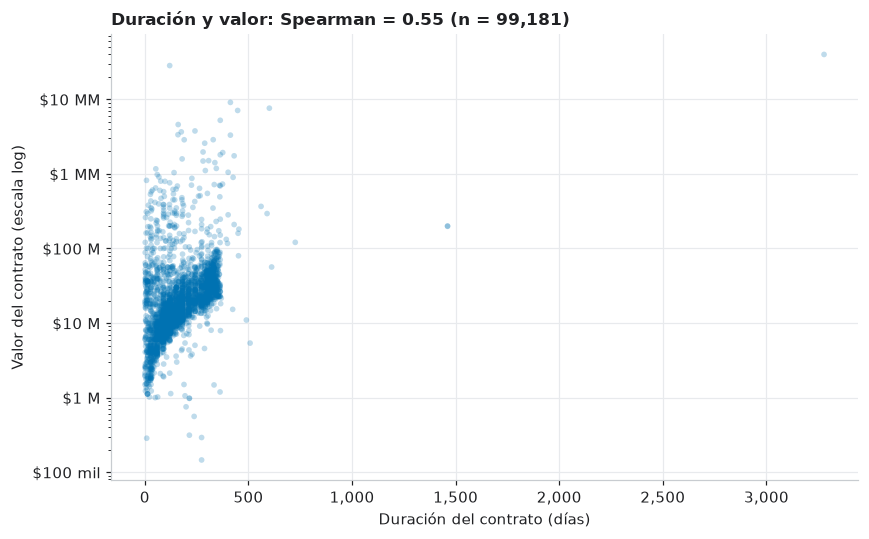

In [23]:
# 🟦 PREPARADA — NUMÉRICA vs. NUMÉRICA

if X and Y:

    pares = df_analisis[[X, Y]].copy()
    pares[X] = pd.to_numeric(pares[X], errors="coerce")
    pares[Y] = pd.to_numeric(pares[Y], errors="coerce")
    pares = pares.dropna()
    pares = pares[(pares[X] > 0) & (pares[Y] > 0)]

    print(f"n = {len(pares):,}")
    print("Correlación de Spearman:", round(pares[X].corr(pares[Y], method="spearman"), 4))

    muestra = pares.sample(min(3000, len(pares)), random_state=42)

    plt.figure(figsize=(8, 5))
    plt.scatter(muestra[X], muestra[Y], alpha=0.25, s=14, color=AZUL, edgecolors="none")
    plt.yscale("log")
    plt.xlabel("Duración del contrato (días)")
    plt.ylabel("Valor del contrato (escala log)")
    plt.title(f"Duración y valor: Spearman = {pares[X].corr(pares[Y], method='spearman'):.2f} (n = {len(pares):,})")
    ejes_legibles(plt.gca(), x="miles", y="pesos")
    plt.show()

else:
    print("Esta comparación no fue configurada.")

## 11.2 Categórica vs. numérica — valor por modalidad

In [24]:
# 🟦 PREPARADA — CATEGÓRICA vs. NUMÉRICA

if GRUPO and Y:

    datos = df_analisis[[GRUPO, Y]].copy()
    datos[Y] = pd.to_numeric(datos[Y], errors="coerce")
    datos = datos.dropna()
    datos = datos[datos[Y] > 0]

    resumen = (
        datos.groupby(GRUPO)[Y]
        .agg(["count", "median", "mean"])
        .sort_values("count", ascending=False)
        .head(10)
    )
    resumen["median"] = resumen["median"].map(pesos)
    resumen["mean"] = resumen["mean"].map(pesos)

    display(resumen.rename(columns={"count": "n", "median": "mediana", "mean": "media"}))

else:
    print("Esta comparación no fue configurada.")

,n,mediana,media
modalidad_de_contratacion,,,
Contratación directa,71160,$17.2 M,$61.9 M
Contratación régimen especial,18231,$12.0 M,$57.4 M
Mínima cuantía,6840,$28.0 M,$30.3 M
Selección Abreviada de Menor Cuantía,1520,$230.1 M,$309.3 M
Contratación Directa (con ofertas),791,$130.0 M,$869.0 M
Selección abreviada subasta inversa,784,$194.8 M,$376.3 M
Contratación régimen especial (con ofertas),705,$282.0 M,$943.8 M
Licitación pública,338,$1.5 MM,$3.7 MM
Concurso de méritos abierto,252,$190.2 M,$429.8 M


## 11.3 Categórica vs. categórica — modalidad y tipo de contrato

Esta es la tabla que da cuerpo a la objeción: muestra que la modalidad está atada al objeto.

In [25]:
# 🟦 PREPARADA — CATEGÓRICA vs. CATEGÓRICA

if VARIABLE_CATEGORICA and VARIABLE_CATEGORICA_2:

    tipos = df_analisis[VARIABLE_CATEGORICA_2].value_counts().head(6).index

    tabla = pd.crosstab(
        df_analisis.loc[df_analisis[VARIABLE_CATEGORICA_2].isin(tipos), VARIABLE_CATEGORICA_2],
        df_analisis.loc[df_analisis[VARIABLE_CATEGORICA_2].isin(tipos), "es_directa"],
        normalize="index",
    ).mul(100).round(1)

    tabla.columns = ["% otras modalidades", "% contratación directa"]
    tabla["n"] = df_analisis[VARIABLE_CATEGORICA_2].value_counts().reindex(tabla.index)

    display(tabla.sort_values("% contratación directa", ascending=False))

else:
    print("Esta comparación no fue configurada.")

,% otras modalidades,% contratación directa,n
tipo_de_contrato,,,
Otro,9.9,90.1,2876
Prestación de servicios,15.8,84.2,81175
Obra,74.9,25.1,1151
Compraventa,97,3,2332
Suministros,99.3,0.7,3166
Decreto 092 de 2017,100,0,8598


## 11.4 🟨 EQUIPO — La prueba de la objeción: estratificar por la confusora

Comparación cruda frente a comparación dentro de estratos donde Z es aproximadamente constante
(cápsula 2, diap. 11).

In [26]:
# 🟥 NO BORRAR — PRUEBA DE LA OBJECIÓN: I1 ESTRATIFICADO POR TIPO DE CONTRATO

alc_contratos = territorial[
    (territorial.clase_entidad == "Alcaldía/Municipio")
    & (territorial[VARIABLE_ENTIDAD].isin(alcaldias.index))
].copy()

alc_contratos["es_pss"] = alc_contratos[VARIABLE_CATEGORICA_2].eq("Prestación de servicios")

# ¿La confusora está realmente ligada a X y a Y? (cápsula 2, diap. 10)
print("PASO 1 — ¿Z está ligada a Y?  % de contratación directa por estrato:")
display(
    alc_contratos.groupby("es_pss")
    .agg(n=("id_contrato", "size"), p_directa=("es_directa", "mean"))
    .rename(index={True: "Prestación de servicios", False: "Todos los demás objetos"})
    .assign(p_directa=lambda t: (t.p_directa * 100).round(1))
    .rename(columns={"p_directa": "% directa"})
)

comp_ent = alc_contratos.groupby(VARIABLE_ENTIDAD).agg(
    n=("id_contrato", "size"),
    share_pss=("es_pss", "mean"),
    p_directa=("es_directa", "mean"),
)
rho = comp_ent.share_pss.corr(comp_ent.p_directa, method="spearman")
print(f"PASO 2 — ¿Z está ligada a X?  Spearman(% prestación de servicios, I1) entre entidades = {rho:.3f}")
print(f"          (n = {len(comp_ent)} alcaldías comparables)")

# PASO 3 — la comparación dentro de estratos
MIN_ESTRATO = 50

def perfil_estrato(sub, minimo):
    g = sub.groupby(VARIABLE_ENTIDAD).agg(n=("id_contrato", "size"), p_directa=("es_directa", "mean"))
    return g[g.n >= minimo]

pss = perfil_estrato(alc_contratos[alc_contratos.es_pss], MIN_ESTRATO)
no_pss = perfil_estrato(alc_contratos[~alc_contratos.es_pss], MIN_ESTRATO)

foco = comp_ent.p_directa.idxmax()   # la entidad señalada en E1

comparacion = pd.DataFrame({
    "mediana del grupo": [comp_ent.p_directa.median(), pss.p_directa.median(), no_pss.p_directa.median()],
    foco.title(): [comp_ent.p_directa[foco], pss.p_directa[foco], no_pss.p_directa[foco]],
    "n del grupo": [len(comp_ent), len(pss), len(no_pss)],
}, index=["CRUDO (todos los contratos)",
          "Estrato: prestación de servicios",
          "Estrato: todos los demás objetos"])

comparacion["distancia (pp)"] = (comparacion[foco.title()] - comparacion["mediana del grupo"]) * 100
comparacion["mediana del grupo"] = (comparacion["mediana del grupo"] * 100).round(1)
comparacion[foco.title()] = (comparacion[foco.title()] * 100).round(1)
comparacion["distancia (pp)"] = comparacion["distancia (pp)"].round(1)

print("\nPASO 3 — LA COMPARACIÓN JUSTA:")
display(comparacion)

# El ranking de priorización, recalculado dentro del estrato que sí discrimina
med = no_pss.p_directa.median()
mad = (no_pss.p_directa - med).abs().median()
no_pss = no_pss.assign(z=(no_pss.p_directa - med) / (1.4826 * mad))

print(f"\nRanking en el estrato 'todos los demás objetos' (mediana del grupo = {med:.1%}):")
display(
    no_pss.nlargest(8, "p_directa")
    .assign(**{"% directa": lambda t: (t.p_directa * 100).round(1)})[["n", "% directa", "z"]]
    .round(2)
)
print(f"Entidades con z >= 2 en este estrato: {(no_pss.z >= 2).sum()}")

PASO 1 — ¿Z está ligada a Y?  % de contratación directa por estrato:


,n,% directa
es_pss,,
Todos los demás objetos,7570,40.4
Prestación de servicios,46234,95.1


PASO 2 — ¿Z está ligada a X?  Spearman(% prestación de servicios, I1) entre entidades = 0.877
          (n = 52 alcaldías comparables)

PASO 3 — LA COMPARACIÓN JUSTA:


,mediana del grupo,Municipio De Soacha.,n del grupo,distancia (pp)
CRUDO (todos los contratos),82.7,97.4,52,14.7
Estrato: prestación de servicios,94.7,98.8,52,4.1
Estrato: todos los demás objetos,37.1,67.9,50,30.8



Ranking en el estrato 'todos los demás objetos' (mediana del grupo = 37.1%):


,n,% directa,z
nombre_entidad,,,
MUNICIPIO DE SOACHA.,268,67.9,1.7
MUNICIPIO DE TOCANCIPA,109,63.3,1.45
MUNICIPIO DE TENJO,227,62.1,1.38
ALCALDÍA MUNICIPAL DE SOPO,125,60.8,1.31
ALCALDÍA MUNICIPAL DE MADRID CUNDINAMARCA,181,60.8,1.31
ALCALDIA MUNICIPAL DE CHIA,278,60.4,1.29
MUNICIPIO DE SUBACHOQUE,147,55.1,1
ALCALDIA MUNICIPIO DE CAJICA,344,53.5,0.91


Entidades con z >= 2 en este estrato: 0


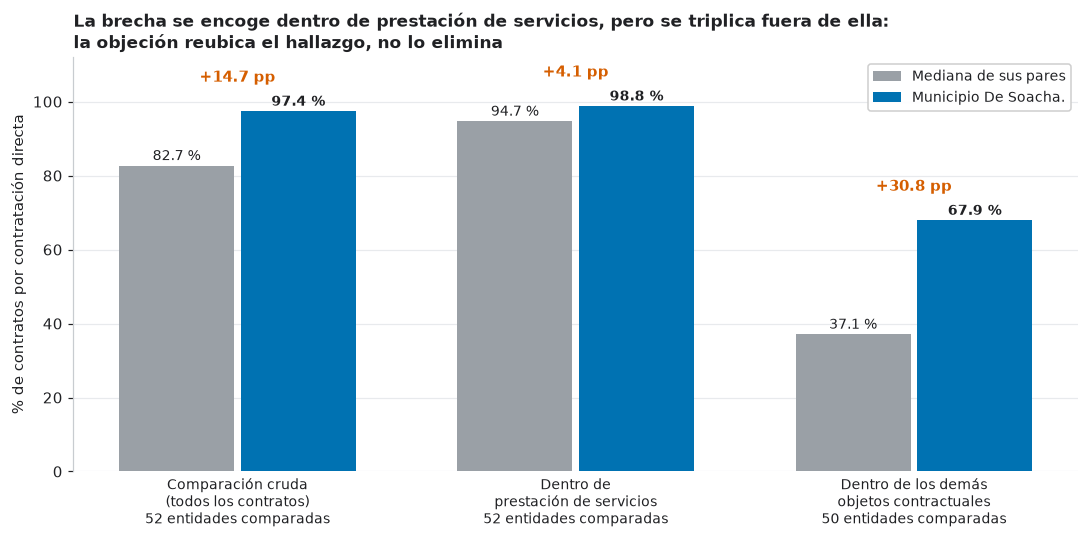

In [27]:
# 🟥 FIGURA CENTRAL DEL VEREDICTO — responde la objeción, mismos grupos, misma escala, n visible

fig, ax = plt.subplots(figsize=(10, 5))

med_vals = comparacion["mediana del grupo"].values
foco_vals = comparacion[foco.title()].values
ns = comparacion["n del grupo"].values

# el n de cada grupo va dentro de la propia etiqueta del eje, no como texto suelto
etiquetas = [f"Comparación cruda\n(todos los contratos)\n{ns[0]} entidades comparadas",
             f"Dentro de\nprestación de servicios\n{ns[1]} entidades comparadas",
             f"Dentro de los demás\nobjetos contractuales\n{ns[2]} entidades comparadas"]

x = np.arange(3)
ancho = 0.34

b1 = ax.bar(x - ancho / 2 - 0.01, med_vals, ancho, color=GRIS,
            label=f"Mediana de sus pares")
b2 = ax.bar(x + ancho / 2 + 0.01, foco_vals, ancho, color=AZUL,
            label=foco.title())

for xi, (m, f) in enumerate(zip(med_vals, foco_vals)):
    ax.text(xi - ancho / 2 - 0.01, m + 1.5, f"{m:.1f} %", ha="center", fontsize=9, color=TINTA)
    ax.text(xi + ancho / 2 + 0.01, f + 1.5, f"{f:.1f} %", ha="center", fontsize=9,
            color=TINTA, fontweight="bold")
    ax.text(xi, max(m, f) + 8, f"{f - m:+.1f} pp", ha="center", fontsize=10,
            color=BERMELLON, fontweight="bold")

ax.set_ylim(0, 112)
ax.set_xticks(x, etiquetas, fontsize=9)
ax.set_ylabel("% de contratos por contratación directa")
ax.set_title(
    "La brecha se encoge dentro de prestación de servicios, pero se triplica fuera de ella:\n"
    "la objeción reubica el hallazgo, no lo elimina",
    fontsize=11,
)
ax.legend(fontsize=9, loc="upper right", framealpha=0.95)
ax.grid(axis="x", visible=False)
ax.spines["bottom"].set_visible(False)
ax.tick_params(axis="x", length=0)

plt.show()

### 🟨 EQUIPO — responder la objeción

**¿La confusora es real?** Sí, y es fuerte. Dentro de las alcaldías comparables, la contratación
directa cubre el **95,1 %** de los contratos de prestación de servicios y solo el **40,4 %** de los
demás objetos. Entre entidades, la correlación de Spearman entre "qué proporción de su contratación
es prestación de servicios" y "qué proporción tramita por directa" es **0,877** (n = 52). La objeción
tenía razón en su premisa: **I1 estaba midiendo, en buena medida, composición del objeto contractual.**

**¿El hallazgo inicial se mantiene, se debilita o desaparece?** **Se debilita y se reubica.**

- **Crudo:** el máximo del grupo (Soacha, 97,4 %) está **+14,7 puntos porcentuales** por encima de la
  mediana de sus pares (82,7 %).
- **Dentro de prestación de servicios:** la brecha cae a **+4,1 pp** (98,8 % frente a una mediana de
  grupo de 94,7 %). Aquí la objeción gana: casi todas las alcaldías están por encima del 94 %, y
  destacar no significa nada.
- **Fuera de prestación de servicios:** la brecha **sube a +30,8 pp** (67,9 % frente a una mediana de
  grupo de 37,1 %). Este estrato —obra, suministros, compraventa, consultoría— es precisamente donde
  las modalidades competitivas son la vía ordinaria, y donde la elección de modalidad **sí** admite
  margen de decisión.

**¿Qué explicación alternativa apareció?** Que el indicador I1 crudo es en gran parte un reflejo de
la **estructura de plantilla** de cada municipio (cuánta de su operación se sostiene con contratos de
prestación de servicios), lo cual es una característica administrativa y presupuestal, no un indicio
de atipicidad.

**Consecuencia práctica: el indicador cambia.** Para el cliente, el indicador útil **no** es "% de
contratación directa", sino **"% de contratación directa en contratos que no son de prestación de
servicios"**. Con ese indicador la lista corta se reordena y se concentra en seis alcaldías
—Soacha, Tocancipá, Tenjo, Sopó, Madrid y Chía— todas entre el 60 % y el 68 %, frente a una mediana
de grupo del 37 %. Aun así, **ninguna alcanza z ≥ 2** dentro del estrato: el umbral que fijamos en
§2.1 sigue sin cruzarse.

# 12. Incertidumbre y causalidad

**¿Qué NO puede concluirse con estos datos?**
> No puede concluirse que ninguna entidad del recorte haya actuado de forma irregular, indebida o
> ilegal. Tampoco que usar contratación directa con más frecuencia que los pares **cause** peores
> resultados de contratación: el recorte no contiene ninguna variable de resultado (calidad,
> cumplimiento, sobrecostos, hallazgos de control). Lo único que puede afirmarse es que **el perfil
> contractual observable de un puñado de entidades se aparta del de sus pares en un estrato
> específico**, y que ese apartamiento es lo bastante consistente como para justificar **mirar
> primero ahí** si el cliente tiene capacidad limitada de revisión.

**¿Qué variable podría estar confundiendo la relación observada?**
> Ya controlamos la composición del objeto contractual (`tipo_de_contrato`), que resultó ser una
> confusora fuerte. Quedan al menos tres sin controlar, de las cuatro sospechosas típicas
> (cápsula 2, diap. 10):
> 1. **Tamaño y capacidad fiscal del municipio.** No está en SECOP y no pudimos normalizar por ella.
> 2. **Capacidad institucional de la oficina de contratación.** Un municipio sin equipo jurídico
>    suficiente puede recurrir a la vía más simple por limitación operativa y no por discrecionalidad.
> 3. **La vigencia.** 2024 es el primer año de las administraciones municipales elegidas en octubre
>    de 2023; el patrón de contratación del primer año de gobierno no tiene por qué parecerse al del
>    segundo, y no separamos ambos años en el indicador.

**¿Qué información adicional sería útil?**
> El presupuesto y la categoría de ley de cada municipio (para normalizar cuantías), la planta de
> personal (para distinguir "poca planta" de "mucha prestación de servicios"), la tabla de
> **adiciones y modificaciones** (`cb9c-h8sn`, la que usa el Expediente D) para ver si la modalidad
> se asocia con adiciones posteriores, y cualquier variable de resultado del contrato.

> Una asociación observada en SECOP no demuestra causalidad.

# 13. Potencia — aproximación operacional

El brief del Expediente C no pide diseñar un experimento de dos grupos, así que esta sección se usa
como **chequeo de honestidad sobre las cuantías**: ¿cuántos contratos harían falta para poder
afirmar que una diferencia de valor entre modalidades es real?

In [28]:
# 🟨 EQUIPO — POTENCIA

from statsmodels.stats.power import TTestIndPower

VARIABLE_RESULTADO = VARIABLE_NUMERICA
VARIABLE_GRUPO = VARIABLE_CATEGORICA

GRUPO_A = "Contratación directa"
GRUPO_B = "Mínima cuantía"

# Diferencia mínima que tendría importancia práctica para el cliente.
DIFERENCIA_RELEVANTE = 5_000_000   # cinco millones de pesos

if GRUPO_A is not None and GRUPO_B is not None and DIFERENCIA_RELEVANTE is not None:

    base = alc_contratos[alc_contratos[VARIABLE_GRUPO].isin([GRUPO_A, GRUPO_B])]
    muestra = pd.to_numeric(base[VARIABLE_RESULTADO], errors="coerce").dropna()

    desviacion = muestra.std()
    if desviacion <= 0:
        raise ValueError("No es posible calcular la potencia con desviación estándar cero.")

    tamano_efecto = DIFERENCIA_RELEVANTE / desviacion
    n = TTestIndPower().solve_power(effect_size=tamano_efecto, alpha=0.05, power=0.80, ratio=1.0)

    n_a = int((base[VARIABLE_GRUPO] == GRUPO_A).sum())
    n_b = int((base[VARIABLE_GRUPO] == GRUPO_B).sum())

    print(f"Desviación estándar del valor : {pesos(desviacion)}")
    print(f"Diferencia relevante          : {pesos(DIFERENCIA_RELEVANTE)}")
    print(f"Tamaño de efecto (d de Cohen) : {tamano_efecto:.4f}")
    print(f"\nObservaciones necesarias por grupo: {int(np.ceil(n)):,}")
    print(f"Observaciones disponibles: {GRUPO_A} = {n_a:,} | {GRUPO_B} = {n_b:,}")

    print(f"\nMedianas reales — {GRUPO_A}: "
          f"{pesos(pd.to_numeric(base.loc[base[VARIABLE_GRUPO]==GRUPO_A, VARIABLE_RESULTADO]).median())}"
          f" | {GRUPO_B}: "
          f"{pesos(pd.to_numeric(base.loc[base[VARIABLE_GRUPO]==GRUPO_B, VARIABLE_RESULTADO]).median())}")

else:
    print("Complete GRUPO_A, GRUPO_B y DIFERENCIA_RELEVANTE si esta comparación aplica.")

Desviación estándar del valor : $897.8 M
Diferencia relevante          : $5.0 M
Tamaño de efecto (d de Cohen) : 0.0056

Observaciones necesarias por grupo: 506,108
Observaciones disponibles: Contratación directa = 46,481 | Mínima cuantía = 3,809

Medianas reales — Contratación directa: $16.5 M | Mínima cuantía: $31.0 M


### 🟨 EQUIPO — lectura del cálculo de potencia

El resultado es deliberadamente incómodo y **es en sí mismo una limitación de la tarjeta de
veredicto**: con una desviación estándar de aproximadamente **\$898 millones** —dominada por la cola
de megacontratos—, detectar una diferencia de \$5 millones exige un tamaño de efecto de
**d ≈ 0,006**, es decir cerca de **506.000 contratos por grupo**. Tenemos 46.481 y 3.809.

La lectura correcta **no** es "hacen falta más datos". Es que **la prueba está mal planteada sobre la
variable en bruto**: con colas de este grosor, la media y la *t* de Student no son la herramienta.
Lo que sí es informativo es la comparación de **medianas** (\$16,5 M en contratación directa frente a
\$31,0 M en mínima cuantía — la modalidad "menor" tiene la cuantía típica **mayor**, porque la
directa arrastra decenas de miles de contratos pequeños de prestación de servicios), o el mismo
contraste sobre el **logaritmo** del valor. Esta es la razón
por la que todo el cuaderno reporta medianas y percentiles y nunca medias solas (cápsula 1, diap. 10;
cápsula 2, diap. 5).

# 14. ¿Cómo obtendría evidencia causal más fuerte?

**Experimento ideal.**
> Si fuera ética, legal y operativamente posible: tomar el conjunto de necesidades de contratación de
> un municipio que **admitan legalmente más de una modalidad**, y **asignar al azar** cuáles se
> tramitan por contratación directa y cuáles por una modalidad competitiva. La aleatorización
> repartiría por igual las confusoras —tipo de objeto, urgencia, capacidad de la oficina, tamaño del
> municipio— entre los dos grupos, de modo que cualquier diferencia posterior fuera atribuible a la
> modalidad (cápsula 2, diap. 14).
>
> Es inviable, y no solo por costo: la modalidad de contratación **está determinada por la ley**
> según el objeto y la cuantía. Escribir el experimento sirve para ver con claridad qué es lo que
> realmente estamos afirmando y qué no.

**Variable resultado.**
> Una sola, definida antes de mirar: el **sobrecosto relativo del contrato**, medido como el
> porcentaje de adición sobre el valor inicial a la terminación
> (`valor final / valor inicial − 1`). Es observable, está definida para todo contrato y se puede
> construir con la tabla de adiciones de SECOP (`cb9c-h8sn`).

**Alternativa factible.**
> Una comparación observacional **emparejada**: para cada contrato tramitado por directa, buscar
> contratos de otras entidades con el **mismo tipo de contrato**, **misma franja de cuantía**,
> **misma vigencia** y **clase de entidad comparable**, tramitados por modalidad competitiva, y
> comparar el sobrecosto solo entre esos pares. Es la extensión natural de lo que ya hicimos en la
> sección 11.4: pasar de estratificar por una variable a emparejar por varias. La conclusión honesta
> que permitiría es la de la cápsula 2 (diap. 14): *"la asociación persiste tras controlar por Z; los
> datos no permiten afirmar causalidad"*.

**Potencia.**
> La diferencia que consideramos relevante fue de **\$5 millones** sobre el valor del contrato, y el
> cálculo devolvió **≈ 506.000 contratos por grupo** (d ≈ 0,006) — un resultado que dice más sobre la
> variable elegida que sobre el tamaño de muestra. Sobre el **logaritmo** del valor, o sobre una
> variable de resultado acotada como el porcentaje de sobrecosto, el tamaño de efecto sería de un
> orden manejable. La lección operativa para la semana 2 es la de la cápsula 2 (diap. 15): **sin
> potencia, no encontrar diferencia no prueba nada**, y la potencia depende tanto de la variable
> elegida como del número de observaciones.

# 15. Evidence Card — veredicto final

**Afirmación investigada:**
> *Algunas entidades del recorte presentan patrones contractuales que justifican una revisión
> prioritaria.*

## Veredicto

- [ ] Respaldada
- [x] **Parcialmente respaldada**
- [ ] No respaldada

**Por qué "parcialmente".** La afirmación **sí** produce una lista corta de entidades defendible y
útil para el cliente, pero **ninguna entidad cruza el umbral de señalamiento que el equipo fijó antes
de mirar los datos** (`z ≥ 2` dentro del grupo de pares). La evidencia alcanza para **ordenar por
dónde empezar**; no alcanza para afirmar que alguna entidad se comporte de forma anómala en un
sentido estadístico fuerte. Bajar el umbral después de ver los resultados habría sido hacer trampa
con nuestro propio criterio.

## Tres evidencias principales

1. **El indicador solo significa algo dentro del grupo de pares (E1).** Las ESE tramitan el 99,7 % de
   sus contratos por régimen especial y las alcaldías el 86,7 % por contratación directa: un ranking
   único del departamento ordena a las entidades por el régimen que les aplica. Formado el grupo de
   52 alcaldías comparables, el máximo (Soacha, 97,4 % sobre 5.857 contratos) queda en z = 1,90,
   por debajo del umbral de 2,0.

2. **La concentración temporal medía cobertura de reporte (E2).** Las cinco entidades que encabezaban
   el ranking crudo reportan entre 3 y 17 meses de 24. Corregido eso, el pico que queda —enero y
   febrero, 37,8 % de las firmas de 2025— es un patrón de todo el departamento, compatible con el
   ciclo presupuestal, y no un rasgo de ninguna entidad.

3. **La objeción reubicó el hallazgo en lugar de destruirlo (sección 11.4).** Controlando por objeto
   contractual, la brecha de Soacha frente a sus pares cae de +14,7 pp a +4,1 pp dentro de prestación
   de servicios, pero **sube a +30,8 pp fuera de ella** (67,9 % frente a 37,1 %), que es justamente el
   terreno donde las modalidades competitivas son la vía ordinaria.

**Visualización central:**
> La figura de la sección 11.4: la misma comparación —entidad señalada frente a la mediana de sus
> pares— repetida en tres marcos (crudo, dentro de prestación de servicios, fuera de ella), en la
> misma escala, con el número de entidades comparadas visible en cada panel y la brecha en puntos
> porcentuales anotada sobre cada par de barras.

**Limitación principal:**
> El recorte **no contiene ninguna variable de resultado del contrato** ni ningún denominador de
> tamaño del municipio. Sin lo primero no puede evaluarse si la modalidad se asocia con peores
> resultados; sin lo segundo, la cuantía mediana por entidad (I3) mide capacidad fiscal antes que
> atipicidad. Se controló una confusora —la composición del objeto contractual— y quedan al menos
> tres declaradas sin controlar (sección 12).

**Recomendación para el cliente (Veeduría Abierta):**
> 1. **Indicador a usar.** Sustituir "% de contratación directa" por **"% de contratación directa en
>    contratos que no son de prestación de servicios"**. El primero ordena a los municipios por su
>    estructura de plantilla; el segundo apunta al margen donde la elección de modalidad sí es una
>    decisión.
> 2. **Lista corta de revisión (6 entidades).** Soacha, Tocancipá, Tenjo, Sopó, Madrid y Chía, todas
>    entre 60 % y 68 % en ese indicador frente a una mediana de grupo del 37 %. **Se entrega como
>    orden de revisión, no como señalamiento:** ninguna cruza el umbral estadístico y todas admiten
>    explicaciones legítimas no descartadas.
> 3. **Lista aparte, de naturaleza distinta.** Las **15 entidades** con reporte incompleto no son un
>    hallazgo de contratación sino de **transparencia**: una entidad que publica en 3 de 24 meses es
>    un asunto de control en sí mismo, y debería tratarse por esa vía y no por esta.
> 4. **Qué pedir a continuación.** Cruzar con la tabla de adiciones (`cb9c-h8sn`) y con la
>    categorización municipal. Sin esas dos fuentes, este recorte ya dio lo que podía dar.

> ⚠️ **Los datos del recorte no permiten imputar irregularidades a ninguna entidad ni persona.**
> Todo lo anterior es priorización de revisión sobre anomalías estadísticas.

# 16. Uso de inteligencia artificial

| Campo | Contenido |
|---|---|
| **Herramienta utilizada** | Claude (Anthropic), asistente de código, en sesión sobre este repositorio. |
| **Actividad en la que se utilizó** | Exploración inicial del recorte; redacción del código de descarga paginada; construcción del panel de indicadores por entidad; generación de las figuras en matplotlib; redacción de los textos del cuaderno. |
| **Resultado que fue verificado y forma de verificación** | **(a)** El conteo del recorte se verificó de forma independiente contra la API de SECOP II con una consulta de agregación (`$select=count(1)`), que devolvió 101.475, coincidiendo con las filas descargadas. **(b)** La regla de clasificación de entidades se auditó imprimiendo todas las entidades de cada clase: así se detectó que la Empresa de Servicios Públicos de Apulo estaba mal clasificada como alcaldía, y se corrigió el orden de las reglas. **(c)** Las entidades que encabezaban el ranking de concentración temporal se revisaron una por una contra su calendario de firmas, lo que reveló que el indicador estaba midiendo cobertura de reporte. **(d)** Todas las cifras de las tarjetas se regeneran ejecutando el cuaderno de principio a fin. |
| **Una decisión del equipo que NO se delegó a la herramienta** | **La definición del criterio previo y del umbral de señalamiento (§2.1), y la decisión de no moverlo al ver los resultados.** Cuando quedó claro que ninguna entidad alcanzaba `z ≥ 2`, la alternativa cómoda era bajar el umbral o cambiar de indicador hasta que algo "saliera". El equipo decidió conservar el criterio registrado y emitir un veredicto de **parcialmente respaldada**. Tampoco se delegó la elección de los pares de comparación ni el lenguaje de la recomendación final, que es deliberadamente de priorización y nunca de señalamiento. |

# 17. Cierre en GitHub

- [x] `Run All` termina sin errores;
- [x] el recorte utilizado está guardado en `data/raw/`;
- [x] las decisiones de preparación están justificadas (sección 7.1);
- [x] E1, E2 y E3 son rastreables;
- [x] la objeción fue respondida (sección 11.4);
- [x] el veredicto reconoce limitaciones (sección 15);
- [x] la declaración de IA está completa (sección 16);
- [x] el historial de commits muestra el proceso.

**Release Semana 1:** `v0.1-evidence`
**Release Semana 2:** `v1.0-verdict`